# 📊 SignAlign - Análise de Experimentos

Este notebook carrega automaticamente todos os experimentos da pasta `experiments/` e permite:

1. **Comparação de métricas** entre diferentes configurações
2. **Visualização de curvas** de treinamento
3. **Análise qualitativa** com attention maps
4. **Matriz de similaridade** para pares específicos


In [204]:
# Imports
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Adicionar path do projeto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.inference import SignaturePredictor, SimilarityMatrixVisualizer, plot_retrieval_results
from src.explainability import visualize_attention
from src.utils.seed import get_device

# Configurações de plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"📁 Diretório do projeto: {project_root}")


📁 Diretório do projeto: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit


# Explore Dataset

In [205]:
dataset = pd.read_csv("../datasets/dataset-sign-align/dataset.csv")
dataset.head()


,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist


### Now, we need to know some information about the dataset 
- How many signature images we have?
- How many signatures names are UNKNOW and not?
- How many different signers there are in the dataset (diffrent names, UNKNOW not included) ?
- What is the mean, median, min and max quantities of signatures per signer?
- How many documnets we have?
- What is the mean, median, min and max quantities of signatures per document?

In [206]:
print("1. How many signature images we have?")
print(f"   Total: {len(dataset)}")

print("\n2. How many signatures names are UNKNOWN and not?")
unknown_count = (dataset['human_name'] == 'UNKNOWN').sum()
not_unknown_count = (dataset['human_name'] != 'UNKNOWN').sum()
print(f"   UNKNOWN: {unknown_count}")
print(f"   Not UNKNOWN: {not_unknown_count}")

print("\n3. How many different signers there are in the dataset (different names, UNKNOWN not included)?")
signers_count = dataset[dataset['human_name'] != 'UNKNOWN']['human_name'].nunique()
print(f"   Different signers: {signers_count}")

print("\n4. What is the mean, median, min and max quantities of signatures per signer?")
signatures_per_signer = dataset[dataset['human_name'] != 'UNKNOWN'].groupby('human_name').size()
print(f"   Mean: {signatures_per_signer.mean():.2f}")
print(f"   Median: {signatures_per_signer.median():.2f}")
print(f"   Min: {signatures_per_signer.min()}")
print(f"   Max: {signatures_per_signer.max()}")

print("\n5. How many documents we have?")
documents_count = dataset['document'].nunique()
print(f"   Total documents: {documents_count}")

print("\n6. What is the mean, median, min and max quantities of signatures per document?")
signatures_per_document = dataset.groupby('document').size()
print(f"   Mean: {signatures_per_document.mean():.2f}")
print(f"   Median: {signatures_per_document.median():.2f}")
print(f"   Min: {signatures_per_document.min()}")
print(f"   Max: {signatures_per_document.max()}")

1. How many signature images we have?
   Total: 4542

2. How many signatures names are UNKNOWN and not?
   UNKNOWN: 895
   Not UNKNOWN: 3647

3. How many different signers there are in the dataset (different names, UNKNOWN not included)?
   Different signers: 753

4. What is the mean, median, min and max quantities of signatures per signer?
   Mean: 4.84
   Median: 1.00
   Min: 1
   Max: 59

5. How many documents we have?
   Total documents: 2241

6. What is the mean, median, min and max quantities of signatures per document?
   Mean: 2.03
   Median: 2.00
   Min: 1
   Max: 8


## 1. 📂 Carregar Experimentos


In [207]:
def load_all_experiments(experiments_dir: str = "../../SigAlignGit/experiments"):
    """Carrega todos os experimentos de um diretório."""
    exp_path = Path(experiments_dir).resolve()
    experiments = []
    
    if not exp_path.exists():
        print(f"⚠️ Diretório {exp_path} não encontrado.")
        return pd.DataFrame()
    
    for exp_dir in exp_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        metadata_path = exp_dir / "metadata.json"
        config_path = exp_dir / "config.json"
        val_history_path = exp_dir / "metrics" / "val_history.json"
        similarity_path = exp_dir / "metrics" / "similarity_stats.json"
        exp_data = {"name": exp_dir.name, "path": str(exp_dir)}
        
        if metadata_path.exists():
            with open(metadata_path) as f:
                metadata = json.load(f)
                exp_data["best_epoch"] = metadata.get("best_epoch")
                exp_data["best_metric"] = metadata.get("best_metric", {})
        
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)
                exp_data["model_type"] = config.get("model", {}).get("type")
                exp_data["model_name"] = config.get("model", {}).get("name")
                exp_data["loss_type"] = config.get("loss", {}).get("primary_loss")
                exp_data["use_triplet"] = config.get("loss", {}).get("use_triplet_loss", False)
                exp_data["triplet_weight"] = config.get("loss", {}).get("triplet_weight", 0.0)
                exp_data["freeze_vision"] = config.get("model", {}).get("freeze_vision_encoder", False)
                exp_data["freeze_text"] = config.get("model", {}).get("freeze_text_encoder", False)
                # Verificar augmentation - pode estar em diferentes lugares
                aug_config = config.get("data", {}).get("augmentation", {})
                if isinstance(aug_config, dict):
                    exp_data["use_augmentation"] = aug_config.get("enabled", True)
                else:
                    exp_data["use_augmentation"] = config.get("data", {}).get("use_augmentation", True)
                
                # Também verificar pelo nome do experimento se tem "noaug"
                if "noaug" in exp_dir.name.lower():
                    exp_data["use_augmentation"] = False
                exp_data["epochs"] = config.get("training", {}).get("epochs", 0)
        
        if val_history_path.exists():
            with open(val_history_path) as f:
                val_history = json.load(f)
                if val_history:
                    for key, value in val_history[-1].items():
                        if key.startswith("val_"):
                            exp_data[key] = value

        if similarity_path.exists():
            with open(similarity_path) as f:
                sim_stats = json.load(f)
                if sim_stats:
                    exp_data["mean_pos_sim"] = sim_stats.get("mean_pos_similarity")
                    exp_data["mean_neg_sim"] = sim_stats.get("mean_neg_similarity")
                    exp_data["median_pos_sim"] = sim_stats.get("median_pos_similarity")
                    exp_data["median_neg_sim"] = sim_stats.get("median_neg_similarity")
                    exp_data["gap_mean"] = sim_stats.get("similarity_gap_mean")
                    exp_data["gap_median"] = sim_stats.get("similarity_gap_median")
                    exp_data["std_pos_sim"] = sim_stats.get("std_pos_similarity")
                    exp_data["std_neg_sim"] = sim_stats.get("std_neg_similarity")

        experiments.append(exp_data)
    
    df = pd.DataFrame(experiments)
    
    # Criar colunas derivadas para facilitar análise
    df["finetuned"] = ~(df["freeze_vision"] & df["freeze_text"])
    df["has_augmentation"] = df["use_augmentation"].fillna(True)
    df["has_triplet"] = df["use_triplet"].fillna(False)
    
    # Extrair arquitetura base do nome do modelo e tipo
    def get_architecture(row):
        name = row.get("model_name", "")
        model_type = row.get("model_type", "")
        
        if pd.isna(name):
            name = ""
        name = name.lower()
        
        # Primeiro verificar por nome específico
        if "tinyclip" in name:
            return "TinyCLIP"
        elif "siglip" in name:
            return "SigLIP"
        elif "patch16" in name or "vit-b-16" in name or "vit_b_16" in name:
            return "CLIP-B/16"
        elif "patch32" in name or "vit-b-32" in name or "vit_b_32" in name:
            return "CLIP-B/32"
        
        # Fallback para model_type
        if model_type == "tinyclip":
            return "TinyCLIP"
        elif model_type == "siglip":
            return "SigLIP"
        elif model_type == "clip":
            return "CLIP-B/32"  # Default CLIP
        
        return "unknown"
    
    df["architecture"] = df.apply(get_architecture, axis=1)
    
    print(f"✅ {len(df)} experimentos carregados.")
    return df

# Carregar experimentos
df_experiments = load_all_experiments()
display(df_experiments[["name", "architecture", "finetuned", "loss_type", "has_triplet", "triplet_weight", "has_augmentation"]].head(10))


✅ 40 experimentos carregados.


,name,architecture,finetuned,loss_type,has_triplet,triplet_weight,has_augmentation
0,siglip_sigmoid,SigLIP,True,sigmoid,False,0.2,True
1,tinyclip_combined_tw03_noaug,TinyCLIP,True,infonce,True,0.3,False
2,clip_vit_b32_combined_tw02_noaug,CLIP-B/32,True,infonce,True,0.2,False
3,clip_vit_b32_infonce_noaug,CLIP-B/32,True,infonce,False,0.2,False
4,tinyclip_combined_tw04_noaug,TinyCLIP,True,infonce,True,0.4,False
5,clip_vit_b16_frozen_eval,CLIP-B/16,False,cross_entropy,False,0.2,False
6,clip_vit_b32_combined_tw02,CLIP-B/32,True,infonce,True,0.2,True
7,tinyclip_combined_tw03,TinyCLIP,True,infonce,True,0.3,True
8,tinyclip_combined_tw02,TinyCLIP,True,infonce,True,0.2,True
9,clip_vit_b32_combined_tw05_noaug,CLIP-B/32,True,infonce,True,0.5,False


---
# 📝 Análise para o Artigo

## Questões de Pesquisa:

1. **RQ1**: Vale a pena fazer fine-tuning? (Frozen vs Finetuned)
2. **RQ2**: Qual arquitetura é melhor? (TinyCLIP vs CLIP vs SigLIP)
3. **RQ3**: Qual a influência da loss combinada com triplet?
4. **RQ4**: A triplet loss melhora a separação de embeddings?
5. **RQ5**: Qual a influência da augmentação de dados?
6. **RQ6**: Qual o melhor modelo final?

---

## 📄 Proposta de Estrutura para Seção de Resultados

### 4.1 Experimental Setup
- Descrição do dataset (Tabela 1)
- Arquiteturas avaliadas (Tabela 2)
- Protocolo de avaliação (Accuracy@k com k negativos)
- Hiperparâmetros de treinamento

### 4.2 Impact of Fine-tuning (RQ1)
- Comparação Frozen vs Finetuned para cada arquitetura
- Figura: Barras comparativas por arquitetura
- **Conclusão**: Quantificar ganho do fine-tuning

### 4.3 Architecture Comparison (RQ2)
- Tabela com resultados baseline de cada arquitetura
- Figura: Radar chart comparativo
- **Conclusão**: Identificar melhor arquitetura base

### 4.4 Combined Loss Analysis (RQ3 + RQ4)
- Impacto do peso da triplet loss (0.1 a 0.5)
- Análise do similarity gap (separação de embeddings)
- Figura: Evolução de métricas por triplet weight
- **Conclusão**: A triplet loss ajudou? Qual o melhor peso?

### 4.5 Data Augmentation Impact (RQ5)
- Comparação com/sem augmentação
- Figura: Barras comparativas
- **Conclusão**: Augmentação é necessária?

### 4.6 Overall Best Configuration (RQ6)
- Ranking final de todos os experimentos
- Tabela: Top-5 modelos
- **Conclusão**: Melhor configuração geral


### RQ1: Vale a pena fazer Fine-tuning?
Comparação entre modelos frozen (pré-treinados sem ajuste) vs finetuned (com ajuste fino)


📊 RQ1: IMPACTO DO FINE-TUNING


,Arquitetura,Acc@1neg (Frozen),Acc@1neg (Finetuned),Δ Acc@1neg,Acc@2neg (Frozen),Acc@2neg (Finetuned),Δ Acc@2neg,Acc@3neg (Frozen),Acc@3neg (Finetuned),Δ Acc@3neg
0,TinyCLIP,0.8584,0.9912,+0.1327,0.7876,0.9558,+0.1681,0.7699,0.9115,+0.1416
1,CLIP-B/32,0.9027,0.9558,+0.0531,0.8319,0.9204,+0.0885,0.7876,0.9027,+0.1150
2,SigLIP,0.5487,0.9381,+0.3894,0.3628,0.8938,+0.5310,0.3097,0.8850,+0.5752


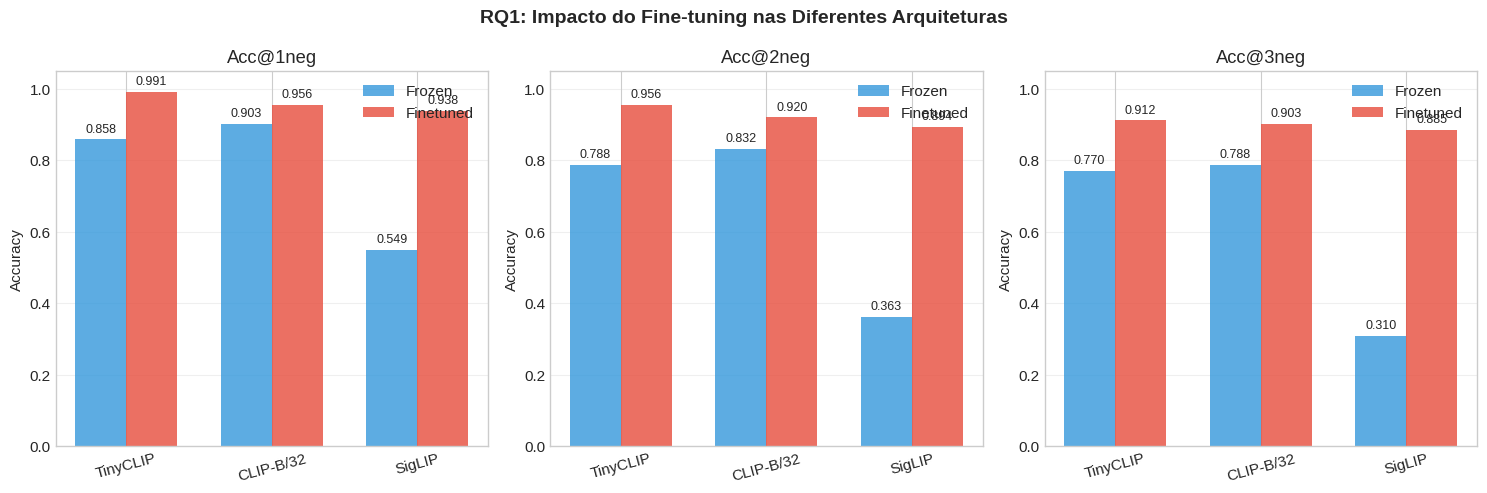

In [208]:
# RQ1: Fine-tuning vs Frozen
# Filtrar apenas experimentos baseline (sem triplet, com augmentação)
def analyze_finetuning_impact():
    """Analisa o impacto do fine-tuning comparando frozen vs finetuned."""
    
    # Separar frozen e finetuned
    frozen = df_experiments[~df_experiments["finetuned"]].copy()
    finetuned = df_experiments[df_experiments["finetuned"]].copy()
    
    # Para comparação justa: usar apenas baseline (sem triplet) com augmentação
    baseline_finetuned = finetuned[
        (~finetuned["has_triplet"]) & 
        (finetuned["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ1: IMPACTO DO FINE-TUNING")
    print("=" * 80)
    
    # Métricas de interesse
    metrics = ["val_accuracy_1_neg", "val_accuracy_2_neg", "val_accuracy_3_neg"]
    metric_labels = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    
    # Criar tabela comparativa
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        frozen_arch = frozen[frozen["architecture"] == arch]
        finetuned_arch = baseline_finetuned[baseline_finetuned["architecture"] == arch]
        
        if len(frozen_arch) > 0 and len(finetuned_arch) > 0:
            row = {"Arquitetura": arch}
            for metric, label in zip(metrics, metric_labels):
                frozen_val = frozen_arch[metric].values[0] if metric in frozen_arch.columns else None
                finetuned_val = finetuned_arch[metric].values[0] if metric in finetuned_arch.columns else None
                
                row[f"{label} (Frozen)"] = f"{frozen_val:.4f}" if frozen_val else "N/A"
                row[f"{label} (Finetuned)"] = f"{finetuned_val:.4f}" if finetuned_val else "N/A"
                
                if frozen_val and finetuned_val:
                    delta = finetuned_val - frozen_val
                    row[f"Δ {label}"] = f"{delta:+.4f}"
            
            results.append(row)
    
    df_results = pd.DataFrame(results)
    display(df_results)
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        # Dados para plot
        archs = []
        frozen_vals = []
        finetuned_vals = []
        
        for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
            frozen_arch = frozen[frozen["architecture"] == arch]
            finetuned_arch = baseline_finetuned[baseline_finetuned["architecture"] == arch]
            
            if len(frozen_arch) > 0 and len(finetuned_arch) > 0:
                archs.append(arch)
                frozen_vals.append(frozen_arch[metric].values[0] if metric in frozen_arch.columns else 0)
                finetuned_vals.append(finetuned_arch[metric].values[0] if metric in finetuned_arch.columns else 0)
        
        x = np.arange(len(archs))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, frozen_vals, width, label='Frozen', color='#3498db', alpha=0.8)
        bars2 = ax.bar(x + width/2, finetuned_vals, width, label='Finetuned', color='#e74c3c', alpha=0.8)
        
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{label}')
        ax.set_xticks(x)
        ax.set_xticklabels(archs, rotation=15)
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3)
        
        # Adicionar valores nas barras
        for bar in bars1 + bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('RQ1: Impacto do Fine-tuning nas Diferentes Arquiteturas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq1_finetuning_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df_results

rq1_results = analyze_finetuning_impact()


### RQ2: Qual arquitetura é a melhor?
Comparação entre TinyCLIP, CLIP-B/32 e SigLIP considerando apenas modelos finetuned baseline (sem triplet, com augmentação)


📊 RQ2: COMPARAÇÃO DE ARQUITETURAS

📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação):


,Arquitetura,Loss,Acc@1neg,Acc@2neg,Acc@3neg,AUC@1neg,AUC@2neg,AUC@3neg
0,TinyCLIP,infonce,0.991150,0.955752,0.911504,0.980343,0.977524,0.974522
1,CLIP-B/32,infonce,0.955752,0.920354,0.902655,0.975253,0.975174,0.974887
2,SigLIP,sigmoid,0.938053,0.893805,0.884956,0.937192,0.938171,0.939306


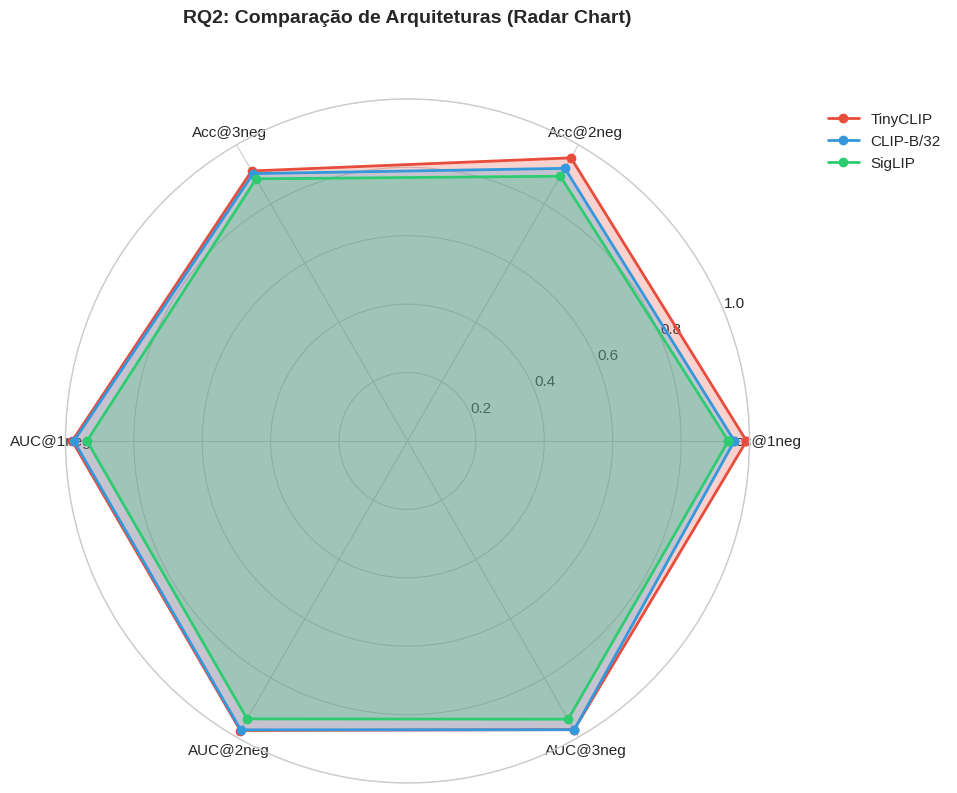


🏆 Melhor arquitetura (Acc@3neg): TinyCLIP


In [209]:
# RQ2: Comparação de Arquiteturas
def analyze_architectures():
    """Compara as diferentes arquiteturas em termos de performance."""
    
    # Filtrar apenas finetuned, baseline (sem triplet), com augmentação
    baseline = df_experiments[
        (df_experiments["finetuned"]) & 
        (~df_experiments["has_triplet"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ2: COMPARAÇÃO DE ARQUITETURAS")
    print("=" * 80)
    
    # Métricas para comparar
    metrics = {
        "val_accuracy_1_neg": "Acc@1neg",
        "val_accuracy_2_neg": "Acc@2neg", 
        "val_accuracy_3_neg": "Acc@3neg",
        "val_auc_1_neg": "AUC@1neg",
        "val_auc_2_neg": "AUC@2neg",
        "val_auc_3_neg": "AUC@3neg"
    }
    
    # Criar tabela
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = baseline[baseline["architecture"] == arch]
        if len(arch_data) > 0:
            row = {"Arquitetura": arch, "Loss": arch_data["loss_type"].values[0]}
            for metric, label in metrics.items():
                if metric in arch_data.columns:
                    row[label] = arch_data[metric].values[0]
            results.append(row)
    
    df_results = pd.DataFrame(results)
    
    # Destacar melhor de cada métrica
    print("\n📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação):")
    display(df_results.style.highlight_max(subset=list(metrics.values()), color='lightgreen'))
    
    # Visualização radar chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    categories = ["Acc@1neg", "Acc@2neg", "Acc@3neg", "AUC@1neg", "AUC@2neg", "AUC@3neg"]
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    for idx, row in df_results.iterrows():
        values = [row.get(cat, 0) for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row["Arquitetura"], color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('RQ2: Comparação de Arquiteturas (Radar Chart)', size=14, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq2_architecture_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Identificar melhor arquitetura
    best_arch = df_results.loc[df_results["Acc@3neg"].idxmax(), "Arquitetura"]
    print(f"\n🏆 Melhor arquitetura (Acc@3neg): {best_arch}")
    
    return df_results

rq2_results = analyze_architectures()


### RQ3: Influência da Loss Combinada (Triplet)
Análise do impacto de usar triplet loss combinada com diferentes pesos (0.1, 0.2, 0.3, 0.4, 0.5)


📊 RQ3: IMPACTO DA TRIPLET LOSS

📈 Resultados por Peso de Triplet Loss:


,Arquitetura,Triplet Weight,Config,Acc@1neg,Acc@2neg,Acc@3neg
6,CLIP-B/32,0.0,Baseline,0.955752,0.920354,0.902655
8,CLIP-B/32,0.1,TW=0.1,0.982301,0.955752,0.929204
7,CLIP-B/32,0.2,TW=0.2,0.973451,0.946903,0.920354
10,CLIP-B/32,0.3,TW=0.3,0.964602,0.938053,0.911504
11,CLIP-B/32,0.4,TW=0.4,0.955752,0.929204,0.911504
9,CLIP-B/32,0.5,TW=0.5,0.982301,0.964602,0.938053
12,SigLIP,0.0,Baseline,0.938053,0.893805,0.884956
15,SigLIP,0.1,TW=0.1,0.955752,0.920354,0.911504
16,SigLIP,0.2,TW=0.2,0.938053,0.893805,0.884956
14,SigLIP,0.3,TW=0.3,0.938053,0.911504,0.902655


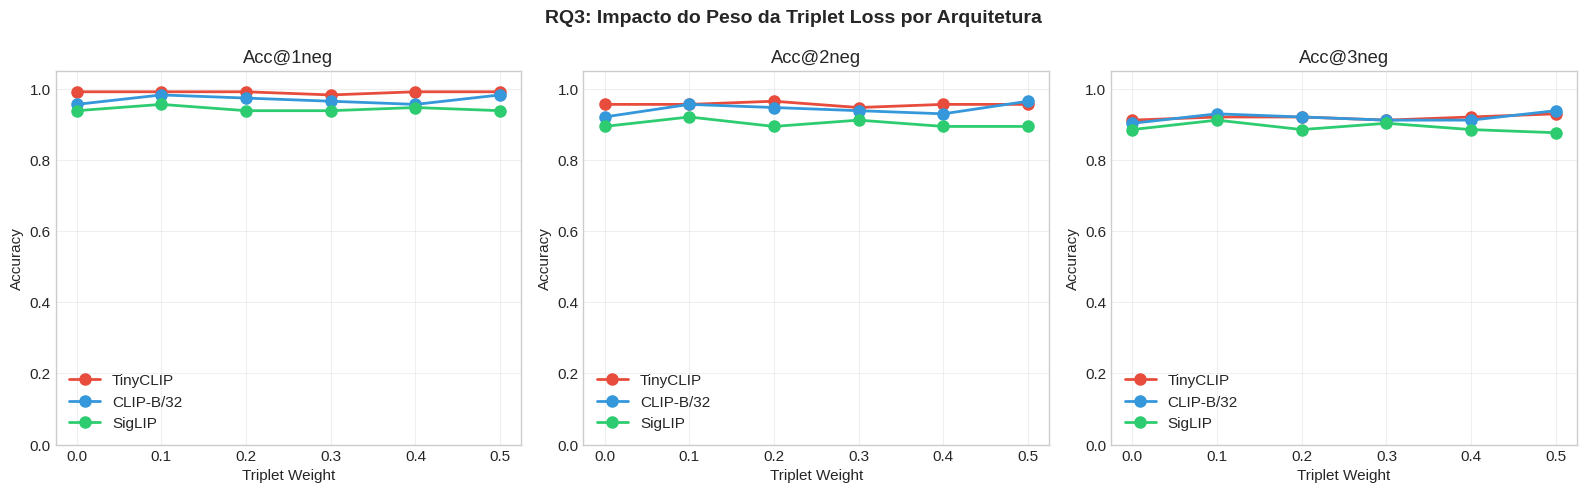


🏆 Melhor configuração por arquitetura (Acc@3neg):
   TinyCLIP: TW=0.5 → Acc@3neg=0.9292
   CLIP-B/32: TW=0.5 → Acc@3neg=0.9381
   SigLIP: TW=0.1 → Acc@3neg=0.9115


In [210]:
# RQ3: Influência da Triplet Loss
def analyze_triplet_loss_impact():
    """Analisa o impacto do peso da triplet loss nas métricas."""
    
    # Filtrar apenas finetuned com augmentação
    finetuned = df_experiments[
        (df_experiments["finetuned"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ3: IMPACTO DA TRIPLET LOSS")
    print("=" * 80)
    
    # Agrupar por arquitetura e triplet weight
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        # Baseline (sem triplet)
        baseline = arch_data[~arch_data["has_triplet"]]
        if len(baseline) > 0:
            row = {
                "Arquitetura": arch,
                "Triplet Weight": 0.0,
                "Config": "Baseline",
                "Acc@1neg": baseline["val_accuracy_1_neg"].values[0] if "val_accuracy_1_neg" in baseline.columns else None,
                "Acc@2neg": baseline["val_accuracy_2_neg"].values[0] if "val_accuracy_2_neg" in baseline.columns else None,
                "Acc@3neg": baseline["val_accuracy_3_neg"].values[0] if "val_accuracy_3_neg" in baseline.columns else None,
            }
            results.append(row)
        
        # Com triplet (diferentes pesos)
        triplet_data = arch_data[arch_data["has_triplet"]]
        for _, exp in triplet_data.iterrows():
            tw = exp.get("triplet_weight", 0)
            row = {
                "Arquitetura": arch,
                "Triplet Weight": tw,
                "Config": f"TW={tw}",
                "Acc@1neg": exp.get("val_accuracy_1_neg"),
                "Acc@2neg": exp.get("val_accuracy_2_neg"),
                "Acc@3neg": exp.get("val_accuracy_3_neg"),
            }
            results.append(row)
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["Arquitetura", "Triplet Weight"])
    
    print("\n📈 Resultados por Peso de Triplet Loss:")
    display(df_results)
    
    # Visualização: linha por arquitetura
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics_plot = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    for idx, metric in enumerate(metrics_plot):
        ax = axes[idx]
        
        for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
            arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
            if len(arch_data) > 0:
                ax.plot(arch_data["Triplet Weight"], arch_data[metric], 
                       'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
        
        ax.set_xlabel('Triplet Weight')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{metric}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 1.05)
    
    plt.suptitle('RQ3: Impacto do Peso da Triplet Loss por Arquitetura', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq3_triplet_loss_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Encontrar melhor configuração por arquitetura
    print("\n🏆 Melhor configuração por arquitetura (Acc@3neg):")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch]
        if len(arch_data) > 0:
            best_idx = arch_data["Acc@3neg"].idxmax()
            best = arch_data.loc[best_idx]
            print(f"   {arch}: TW={best['Triplet Weight']:.1f} → Acc@3neg={best['Acc@3neg']:.4f}")
    
    return df_results

rq3_results = analyze_triplet_loss_impact()


### RQ4: A Triplet Loss melhora a separação de embeddings?
Análise do gap entre similaridades positivas e negativas para avaliar se a triplet loss ajuda a separar melhor os embeddings no hiperespaço.


📊 RQ4: SEPARAÇÃO DE EMBEDDINGS (SIMILARITY GAP)

📈 Estatísticas de Similaridade:


,Arquitetura,Config,Mean Pos Sim,Mean Neg Sim,Gap (Mean),Median Pos Sim,Median Neg Sim,Gap (Median)
10,CLIP-B/32,Baseline,0.3575,0.1258,0.2317,0.3548,0.0655,0.2893
7,CLIP-B/32,TW=0.1,0.4386,0.1506,0.2881,0.4405,0.0639,0.3766
6,CLIP-B/32,TW=0.2,0.3378,0.1263,0.2115,0.3356,0.0723,0.2634
9,CLIP-B/32,TW=0.3,0.4215,0.1404,0.2811,0.4297,0.0632,0.3665
11,CLIP-B/32,TW=0.4,0.4232,0.1410,0.2822,0.4274,0.0549,0.3725
8,CLIP-B/32,TW=0.5,0.4151,0.1405,0.2746,0.4198,0.0647,0.3551
12,SigLIP,Baseline,0.5420,0.3141,0.2279,0.5603,0.3003,0.2600
15,SigLIP,TW=0.1,0.5488,0.3098,0.2389,0.5717,0.2879,0.2839
16,SigLIP,TW=0.2,0.5443,0.3135,0.2308,0.5664,0.2926,0.2737
14,SigLIP,TW=0.3,0.5488,0.3168,0.2320,0.5719,0.2918,0.2801


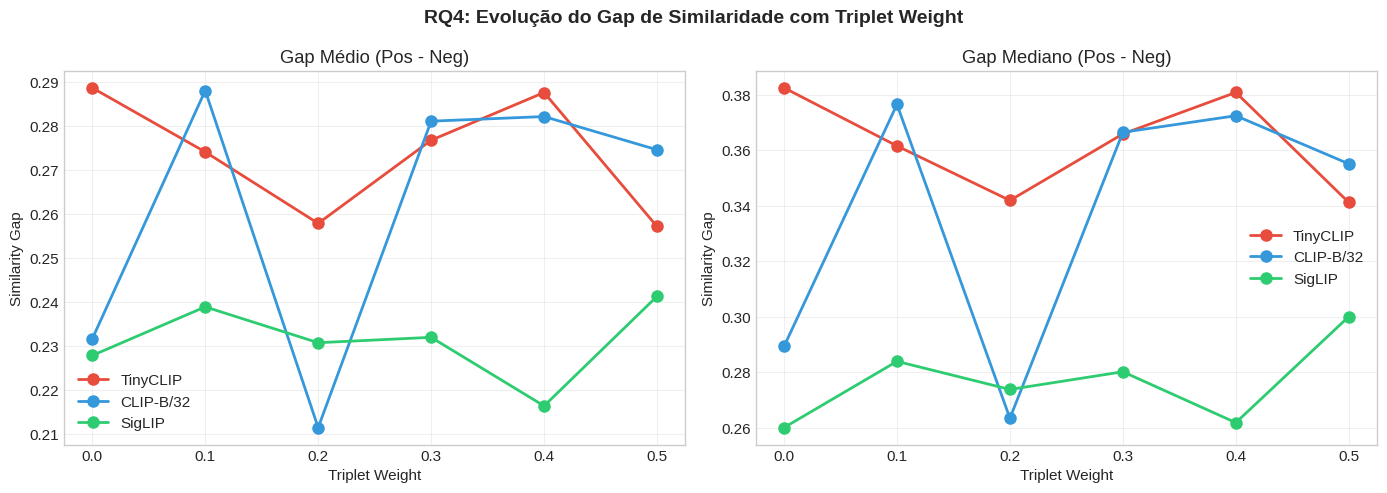

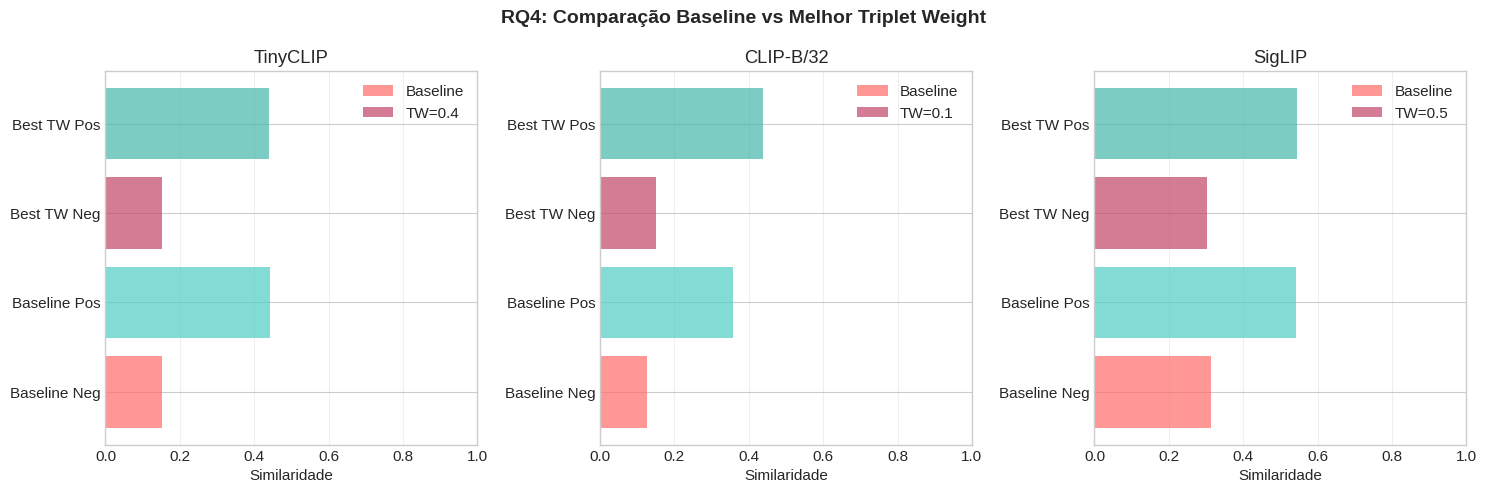


📊 Análise: A Triplet Loss aumentou o gap?
   TinyCLIP: Baseline Gap=0.2887, Best Triplet Gap=0.2876, Δ=-0.0011 ❌ Não melhorou
   CLIP-B/32: Baseline Gap=0.2317, Best Triplet Gap=0.2881, Δ=+0.0564 ✅ Melhorou
   SigLIP: Baseline Gap=0.2279, Best Triplet Gap=0.2413, Δ=+0.0134 ✅ Melhorou


In [212]:
# RQ4: Separação de Embeddings (Análise do Gap)
def analyze_embedding_separation():
    """Analisa se a triplet loss melhora a separação entre embeddings positivos e negativos."""
    
    # Filtrar apenas finetuned com augmentação
    finetuned = df_experiments[
        (df_experiments["finetuned"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ4: SEPARAÇÃO DE EMBEDDINGS (SIMILARITY GAP)")
    print("=" * 80)
    
    # Coletar dados de gap
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        for _, exp in arch_data.iterrows():
            tw = exp.get("triplet_weight", 0) if exp.get("has_triplet", False) else 0
            config = "Baseline" if tw == 0 else f"TW={tw}"
            
            row = {
                "Arquitetura": arch,
                "Triplet Weight": tw,
                "Config": config,
                "Mean Pos Sim": exp.get("mean_pos_sim"),
                "Mean Neg Sim": exp.get("mean_neg_sim"),
                "Gap (Mean)": exp.get("gap_mean"),
                "Median Pos Sim": exp.get("median_pos_sim"),
                "Median Neg Sim": exp.get("median_neg_sim"),
                "Gap (Median)": exp.get("gap_median"),
            }
            results.append(row)
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["Arquitetura", "Triplet Weight"])
    
    print("\n📈 Estatísticas de Similaridade:")
    display(df_results[["Arquitetura", "Config", "Mean Pos Sim", "Mean Neg Sim", "Gap (Mean)", 
                        "Median Pos Sim", "Median Neg Sim", "Gap (Median)"]].round(4))
    
    # Visualização 1: Gap por triplet weight
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    # Gap médio
    ax = axes[0]
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
        if len(arch_data) > 0 and "Gap (Mean)" in arch_data.columns:
            ax.plot(arch_data["Triplet Weight"], arch_data["Gap (Mean)"], 
                   'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
    ax.set_xlabel('Triplet Weight')
    ax.set_ylabel('Similarity Gap')
    ax.set_title('Gap Médio (Pos - Neg)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Gap mediano
    ax = axes[1]
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
        if len(arch_data) > 0 and "Gap (Median)" in arch_data.columns:
            ax.plot(arch_data["Triplet Weight"], arch_data["Gap (Median)"], 
                   'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
    ax.set_xlabel('Triplet Weight')
    ax.set_ylabel('Similarity Gap')
    ax.set_title('Gap Mediano (Pos - Neg)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.suptitle('RQ4: Evolução do Gap de Similaridade com Triplet Weight', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq4_similarity_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Visualização 2: Distribuição de similaridades (baseline vs melhor triplet)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, arch in enumerate(["TinyCLIP", "CLIP-B/32", "SigLIP"]):
        ax = axes[idx]
        arch_data = df_results[df_results["Arquitetura"] == arch]
        
        if len(arch_data) > 0:
            # Baseline
            baseline = arch_data[arch_data["Triplet Weight"] == 0]
            if len(baseline) > 0:
                pos_baseline = baseline["Mean Pos Sim"].values[0]
                neg_baseline = baseline["Mean Neg Sim"].values[0]
                ax.barh(["Baseline Neg", "Baseline Pos"], [neg_baseline, pos_baseline], 
                       color=['#ff6b6b', '#4ecdc4'], alpha=0.7, label='Baseline')
            
            # Melhor triplet
            triplet_data = arch_data[arch_data["Triplet Weight"] > 0]
            if len(triplet_data) > 0:
                best_tw = triplet_data.loc[triplet_data["Gap (Mean)"].idxmax()]
                pos_triplet = best_tw["Mean Pos Sim"]
                neg_triplet = best_tw["Mean Neg Sim"]
                ax.barh(["Best TW Neg", "Best TW Pos"], [neg_triplet, pos_triplet],
                       color=['#c44569', '#45b7aa'], alpha=0.7, label=f'TW={best_tw["Triplet Weight"]}')
        
        ax.set_xlabel('Similaridade')
        ax.set_title(arch)
        ax.set_xlim(0, 1)
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('RQ4: Comparação Baseline vs Melhor Triplet Weight', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq4_similarity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Análise estatística: triplet aumentou o gap?
    print("\n📊 Análise: A Triplet Loss aumentou o gap?")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch]
        baseline_gap = arch_data[arch_data["Triplet Weight"] == 0]["Gap (Mean)"].values
        triplet_gaps = arch_data[arch_data["Triplet Weight"] > 0]["Gap (Mean)"].values
        
        if len(baseline_gap) > 0 and len(triplet_gaps) > 0:
            baseline_gap = baseline_gap[0]
            best_triplet_gap = max(triplet_gaps)
            delta = best_triplet_gap - baseline_gap
            status = "✅ Melhorou" if delta > 0 else "❌ Não melhorou"
            print(f"   {arch}: Baseline Gap={baseline_gap:.4f}, Best Triplet Gap={best_triplet_gap:.4f}, Δ={delta:+.4f} {status}")
    
    return df_results

rq4_results = analyze_embedding_separation()


### RQ5: Influência da Augmentação de Dados
Comparação entre experimentos com e sem data augmentation para avaliar o impacto dessa técnica.


📊 RQ5: IMPACTO DA AUGMENTAÇÃO DE DADOS

📈 Comparação Com/Sem Augmentação:


,Arquitetura,Config,Acc@3neg (Aug),Acc@3neg (NoAug),Δ Acc@3neg
0,TinyCLIP,TW=0.1,0.9204,0.8673,0.0531
1,TinyCLIP,TW=0.2,0.9204,0.8761,0.0442
2,TinyCLIP,TW=0.3,0.9115,0.8761,0.0354
3,TinyCLIP,TW=0.4,0.9204,0.8761,0.0442
4,TinyCLIP,TW=0.5,0.9292,0.8761,0.0531
5,CLIP-B/32,TW=0.1,0.9292,0.8938,0.0354
6,CLIP-B/32,TW=0.2,0.9204,0.8850,0.0354
7,CLIP-B/32,TW=0.3,0.9115,0.8850,0.0265
8,CLIP-B/32,TW=0.4,0.9115,0.8850,0.0265
9,CLIP-B/32,TW=0.5,0.9381,0.8850,0.0531


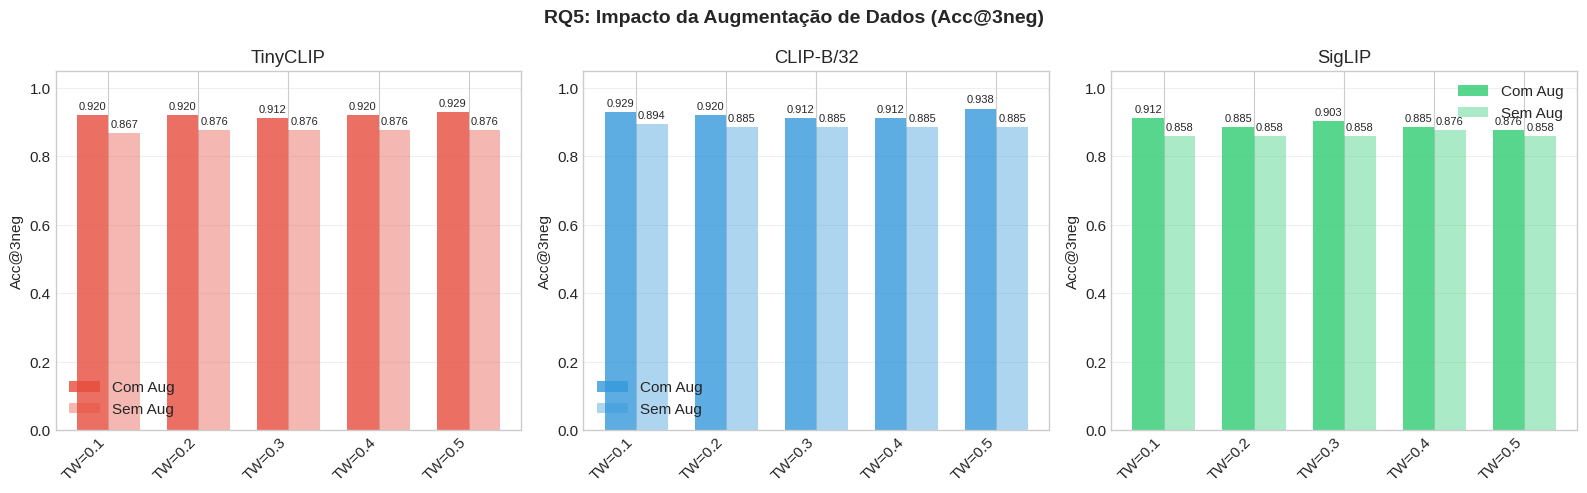


📊 Análise: Augmentação ajudou?
   Δ médio: +0.0372
   Casos onde augmentação ajudou: 15/15 (100.0%)


In [213]:
# RQ5: Influência da Augmentação de Dados
def analyze_augmentation_impact():
    """Analisa o impacto da augmentação de dados nas métricas."""
    
    # Filtrar apenas finetuned
    finetuned = df_experiments[df_experiments["finetuned"]].copy()
    
    print("=" * 80)
    print("📊 RQ5: IMPACTO DA AUGMENTAÇÃO DE DADOS")
    print("=" * 80)
    
    # Comparar com e sem augmentação para cada configuração
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        # Agrupar por triplet weight
        for tw in sorted(arch_data["triplet_weight"].unique()):
            tw_data = arch_data[arch_data["triplet_weight"] == tw]
            
            with_aug = tw_data[tw_data["has_augmentation"]]
            without_aug = tw_data[~tw_data["has_augmentation"]]
            
            if len(with_aug) > 0 and len(without_aug) > 0:
                config = "Baseline" if tw == 0 else f"TW={tw}"
                
                acc3_aug = with_aug["val_accuracy_3_neg"].values[0] if "val_accuracy_3_neg" in with_aug.columns else None
                acc3_noaug = without_aug["val_accuracy_3_neg"].values[0] if "val_accuracy_3_neg" in without_aug.columns else None
                
                row = {
                    "Arquitetura": arch,
                    "Config": config,
                    "Acc@3neg (Aug)": acc3_aug,
                    "Acc@3neg (NoAug)": acc3_noaug,
                    "Δ Acc@3neg": (acc3_aug - acc3_noaug) if acc3_aug and acc3_noaug else None,
                }
                
                # Adicionar outras métricas
                for metric in ["val_accuracy_1_neg", "val_accuracy_2_neg"]:
                    label = metric.replace("val_", "").replace("_", "@")
                    aug_val = with_aug[metric].values[0] if metric in with_aug.columns else None
                    noaug_val = without_aug[metric].values[0] if metric in without_aug.columns else None
                    row[f"{label} (Aug)"] = aug_val
                    row[f"{label} (NoAug)"] = noaug_val
                
                results.append(row)
    
    df_results = pd.DataFrame(results)
    
    print("\n📈 Comparação Com/Sem Augmentação:")
    display(df_results[["Arquitetura", "Config", "Acc@3neg (Aug)", "Acc@3neg (NoAug)", "Δ Acc@3neg"]].round(4))
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    for idx, arch in enumerate(["TinyCLIP", "CLIP-B/32", "SigLIP"]):
        ax = axes[idx]
        arch_data = df_results[df_results["Arquitetura"] == arch].reset_index(drop=True)
        
        if len(arch_data) > 0:
            x = np.arange(len(arch_data))
            width = 0.35
            
            aug_vals = arch_data["Acc@3neg (Aug)"].fillna(0)
            noaug_vals = arch_data["Acc@3neg (NoAug)"].fillna(0)
            
            bars1 = ax.bar(x - width/2, aug_vals, width, label='Com Aug', color=colors[arch], alpha=0.8)
            bars2 = ax.bar(x + width/2, noaug_vals, width, label='Sem Aug', color=colors[arch], alpha=0.4)
            
            ax.set_ylabel('Acc@3neg')
            ax.set_title(arch)
            ax.set_xticks(x)
            ax.set_xticklabels(arch_data["Config"], rotation=45, ha='right')
            ax.legend()
            ax.set_ylim(0, 1.05)
            ax.grid(axis='y', alpha=0.3)
            
            # Valores nas barras
            for bar in bars1:
                height = bar.get_height()
                if height > 0:
                    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
            for bar in bars2:
                height = bar.get_height()
                if height > 0:
                    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    plt.suptitle('RQ5: Impacto da Augmentação de Dados (Acc@3neg)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq5_augmentation_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Análise: augmentação ajudou em média?
    print("\n📊 Análise: Augmentação ajudou?")
    deltas = df_results["Δ Acc@3neg"].dropna()
    if len(deltas) > 0:
        mean_delta = deltas.mean()
        positive_count = (deltas > 0).sum()
        total = len(deltas)
        print(f"   Δ médio: {mean_delta:+.4f}")
        print(f"   Casos onde augmentação ajudou: {positive_count}/{total} ({100*positive_count/total:.1f}%)")
    
    return df_results

rq5_results = analyze_augmentation_impact()


### RQ6: Qual o melhor modelo final?
Ranking geral de todos os experimentos para identificar a melhor configuração.


📊 RQ6: RANKING FINAL DOS MODELOS

🏆 TOP 10 Modelos (por Acc@3neg):


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Gap (Mean),Gap (Median)
0,1,clip_vit_b32_combined_tw05,CLIP-B/32 | infonce+TW0.5,0.982301,0.964602,0.938053,0.274604,0.355145
1,2,clip_vit_b32_combined_tw01,CLIP-B/32 | infonce+TW0.1,0.982301,0.955752,0.929204,0.288053,0.376567
2,3,tinyclip_combined_tw05,TinyCLIP | infonce+TW0.5,0.991150,0.955752,0.929204,0.257180,0.341192
3,4,clip_vit_b32_combined_tw02,CLIP-B/32 | infonce+TW0.2,0.973451,0.946903,0.920354,0.211502,0.263354
4,5,tinyclip_combined_tw02,TinyCLIP | infonce+TW0.2,0.991150,0.964602,0.920354,0.257887,0.341925
5,6,tinyclip_combined_tw04,TinyCLIP | infonce+TW0.4,0.991150,0.955752,0.920354,0.287610,0.380899
6,7,tinyclip_combined_tw01,TinyCLIP | infonce+TW0.1,0.991150,0.955752,0.920354,0.274118,0.361600
7,8,tinyclip_combined_tw03,TinyCLIP | infonce+TW0.3,0.982301,0.946903,0.911504,0.276775,0.365921
8,9,siglip_combined_tw01,SigLIP | sigmoid+TW0.1,0.955752,0.920354,0.911504,0.238927,0.283870
9,10,clip_vit_b32_combined_tw04,CLIP-B/32 | infonce+TW0.4,0.955752,0.929204,0.911504,0.282152,0.372494



📉 BOTTOM 5 Modelos:


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Gap (Mean),Gap (Median)
35,36,siglip_combined_tw03_noaug,SigLIP | sigmoid+TW0.3 | NoAug,0.902655,0.893805,0.858407,0.243145,0.288626
36,37,siglip_sigmoid_noaug,SigLIP | sigmoid | NoAug,0.902655,0.867257,0.831858,0.197441,0.232130
37,38,clip_vit_b32_frozen_eval,CLIP-B/32 | Frozen,0.902655,0.831858,0.787611,NaN,NaN
38,39,tinyclip_frozen_eval,TinyCLIP | Frozen,0.858407,0.787611,0.769912,NaN,NaN
39,40,siglip_frozen_eval,SigLIP | Frozen,0.548673,0.362832,0.309735,NaN,NaN


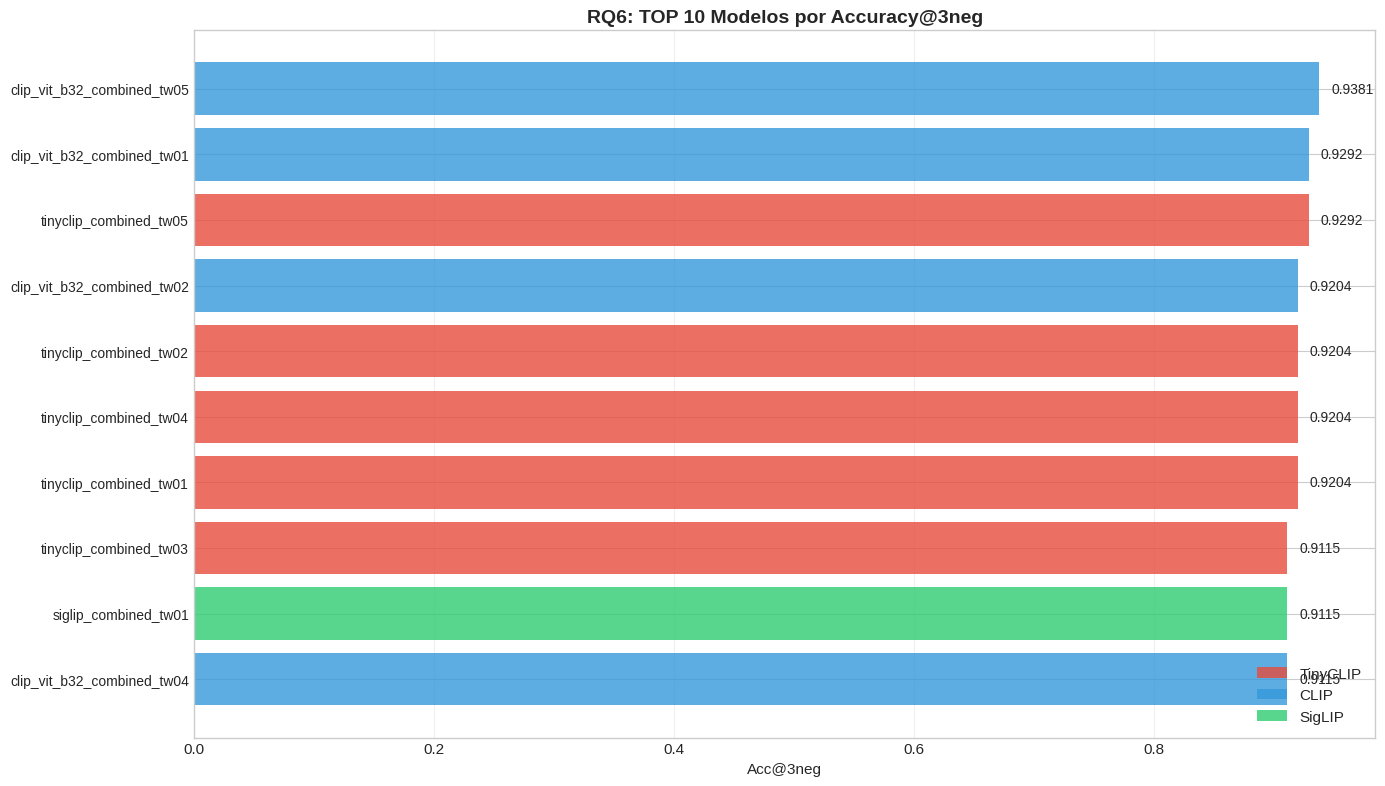


🥇 MELHOR MODELO GERAL:
   Experimento: clip_vit_b32_combined_tw05
   Configuração: CLIP-B/32 | infonce+TW0.5
   Acc@1neg: 0.9823
   Acc@2neg: 0.9646
   Acc@3neg: 0.9381

📊 Resumo por Arquitetura:
   TinyCLIP: Best Acc@3neg=0.9292, Mean=0.8863, Best Rank=3
   CLIP-B/32: Best Acc@3neg=0.9381, Mean=0.8938, Best Rank=1
   SigLIP: Best Acc@3neg=0.9115, Mean=0.8305, Best Rank=9


In [214]:
# RQ6: Ranking Final
def create_final_ranking():
    """Cria ranking final de todos os experimentos."""
    
    print("=" * 80)
    print("📊 RQ6: RANKING FINAL DOS MODELOS")
    print("=" * 80)
    
    # Preparar dados para ranking
    df_ranking = df_experiments.copy()
    
    # Criar coluna de configuração legível
    def get_config_name(row):
        parts = []
        parts.append(row["architecture"])
        if not row["finetuned"]:
            parts.append("Frozen")
        else:
            loss = row.get("loss_type", "unknown")
            if row.get("has_triplet", False):
                tw = row.get("triplet_weight", 0)
                parts.append(f"{loss}+TW{tw}")
            else:
                parts.append(loss)
            if not row.get("has_augmentation", True):
                parts.append("NoAug")
        return " | ".join(parts)
    
    df_ranking["Config"] = df_ranking.apply(get_config_name, axis=1)
    
    # Métricas para ranking
    metrics = ["val_accuracy_1_neg", "val_accuracy_2_neg", "val_accuracy_3_neg"]
    
    # Ordenar por Acc@3neg (métrica principal)
    df_ranking = df_ranking.sort_values("val_accuracy_3_neg", ascending=False).reset_index(drop=True)
    df_ranking["Rank"] = df_ranking.index + 1
    
    # Selecionar colunas para display
    display_cols = ["Rank", "name", "Config", "val_accuracy_1_neg", "val_accuracy_2_neg", 
                   "val_accuracy_3_neg", "gap_mean", "gap_median"]
    
    df_display = df_ranking[display_cols].copy()
    df_display.columns = ["Rank", "Experimento", "Configuração", "Acc@1neg", "Acc@2neg", 
                         "Acc@3neg", "Gap (Mean)", "Gap (Median)"]
    
    print("\n🏆 TOP 10 Modelos (por Acc@3neg):")
    display(df_display.head(10).style.background_gradient(subset=["Acc@3neg"], cmap='Greens'))
    
    print("\n📉 BOTTOM 5 Modelos:")
    display(df_display.tail(5))
    
    # Visualização: Top 10
    fig, ax = plt.subplots(figsize=(14, 8))
    
    top10 = df_display.head(10)
    y_pos = np.arange(len(top10))
    
    # Cores por arquitetura
    def get_color(config):
        if "TinyCLIP" in config:
            return "#e74c3c"
        elif "CLIP" in config:
            return "#3498db"
        elif "SigLIP" in config:
            return "#2ecc71"
        return "#95a5a6"
    
    colors = [get_color(c) for c in top10["Configuração"]]
    
    bars = ax.barh(y_pos, top10["Acc@3neg"], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10["Experimento"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Acc@3neg')
    ax.set_title('RQ6: TOP 10 Modelos por Accuracy@3neg', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Valores nas barras
    for bar, val in zip(bars, top10["Acc@3neg"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=10)
    
    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', alpha=0.8, label='TinyCLIP'),
        Patch(facecolor='#3498db', alpha=0.8, label='CLIP'),
        Patch(facecolor='#2ecc71', alpha=0.8, label='SigLIP'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq6_final_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Melhor modelo
    best = df_display.iloc[0]
    print(f"\n🥇 MELHOR MODELO GERAL:")
    print(f"   Experimento: {best['Experimento']}")
    print(f"   Configuração: {best['Configuração']}")
    print(f"   Acc@1neg: {best['Acc@1neg']:.4f}")
    print(f"   Acc@2neg: {best['Acc@2neg']:.4f}")
    print(f"   Acc@3neg: {best['Acc@3neg']:.4f}")
    
    # Estatísticas por arquitetura
    print("\n📊 Resumo por Arquitetura:")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_ranking[df_ranking["architecture"] == arch]
        if len(arch_data) > 0:
            best_acc = arch_data["val_accuracy_3_neg"].max()
            mean_acc = arch_data["val_accuracy_3_neg"].mean()
            best_rank = arch_data["Rank"].min()
            print(f"   {arch}: Best Acc@3neg={best_acc:.4f}, Mean={mean_acc:.4f}, Best Rank={best_rank}")
    
    return df_display

rq6_ranking = create_final_ranking()


## 📝 Resumo para o Artigo
Tabelas e visualizações prontas para exportação.


In [215]:
# Resumo Final para o Artigo
def generate_article_summary():
    """Gera tabelas e resumos formatados para o artigo."""
    
    print("=" * 80)
    print("📄 RESUMO PARA O ARTIGO")
    print("=" * 80)
    
    # 1. Tabela: Dataset Statistics
    print("\n📊 TABELA 1: Estatísticas do Dataset")
    dataset_stats = {
        "Métrica": ["Total de Assinaturas", "Assinaturas Identificadas", "Assinaturas UNKNOWN", 
                    "Signatários Únicos", "Documentos", "Média Assinaturas/Signatário",
                    "Mediana Assinaturas/Signatário"],
        "Valor": [4542, 3647, 895, 753, 2241, 4.84, 1.0]
    }
    df_dataset_stats = pd.DataFrame(dataset_stats)
    display(df_dataset_stats)
    
    # 2. Tabela: Model Architectures
    print("\n📊 TABELA 2: Arquiteturas de Modelos")
    model_info = {
        "Modelo": ["TinyCLIP", "CLIP ViT-B/32", "SigLIP"],
        "Vision Encoder": ["ResNet-8M", "ViT-B/32", "ViT-B/16"],
        "Text Encoder": ["Transformer-8M", "Transformer-63M", "Transformer"],
        "Loss Padrão": ["InfoNCE", "InfoNCE", "Sigmoid"],
        "Embedding Dim": [512, 512, 768]
    }
    df_models = pd.DataFrame(model_info)
    display(df_models)
    
    # 3. Tabela: Main Results (Best per Architecture)
    print("\n📊 TABELA 3: Melhores Resultados por Arquitetura")
    
    main_results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        # Frozen baseline
        frozen = df_experiments[(~df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(frozen) > 0:
            main_results.append({
                "Arquitetura": arch,
                "Configuração": "Frozen (Pre-trained)",
                "Acc@1neg": frozen["val_accuracy_1_neg"].values[0],
                "Acc@2neg": frozen["val_accuracy_2_neg"].values[0],
                "Acc@3neg": frozen["val_accuracy_3_neg"].values[0],
            })
        
        # Best finetuned
        finetuned = df_experiments[(df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(finetuned) > 0:
            best_idx = finetuned["val_accuracy_3_neg"].idxmax()
            best = finetuned.loc[best_idx]
            config = f"Finetuned"
            if best.get("has_triplet", False):
                config += f" + Triplet (w={best['triplet_weight']})"
            if not best.get("has_augmentation", True):
                config += " [NoAug]"
            
            main_results.append({
                "Arquitetura": arch,
                "Configuração": config,
                "Acc@1neg": best["val_accuracy_1_neg"],
                "Acc@2neg": best["val_accuracy_2_neg"],
                "Acc@3neg": best["val_accuracy_3_neg"],
            })
    
    df_main = pd.DataFrame(main_results)
    display(df_main.round(4).style.highlight_max(subset=["Acc@3neg"], color='lightgreen'))
    
    # 4. Conclusões automáticas
    print("\n" + "=" * 80)
    print("📌 CONCLUSÕES PRINCIPAIS")
    print("=" * 80)
    
    # RQ1: Fine-tuning
    frozen_avg = df_experiments[~df_experiments["finetuned"]]["val_accuracy_3_neg"].mean()
    finetuned_avg = df_experiments[df_experiments["finetuned"]]["val_accuracy_3_neg"].mean()
    print(f"\n1. Fine-tuning:")
    print(f"   - Média Acc@3neg Frozen: {frozen_avg:.4f}")
    print(f"   - Média Acc@3neg Finetuned: {finetuned_avg:.4f}")
    print(f"   - Melhoria: {((finetuned_avg - frozen_avg) / frozen_avg * 100):+.1f}%")
    
    # RQ2: Best Architecture
    best_overall = df_experiments.loc[df_experiments["val_accuracy_3_neg"].idxmax()]
    print(f"\n2. Melhor Arquitetura: {best_overall['architecture']}")
    print(f"   - Experimento: {best_overall['name']}")
    print(f"   - Acc@3neg: {best_overall['val_accuracy_3_neg']:.4f}")
    
    # RQ3/RQ4: Triplet Loss
    with_triplet = df_experiments[df_experiments["has_triplet"]]["val_accuracy_3_neg"].mean()
    without_triplet = df_experiments[~df_experiments["has_triplet"] & df_experiments["finetuned"]]["val_accuracy_3_neg"].mean()
    print(f"\n3. Triplet Loss:")
    print(f"   - Média Acc@3neg com Triplet: {with_triplet:.4f}")
    print(f"   - Média Acc@3neg sem Triplet: {without_triplet:.4f}")
    
    # RQ5: Augmentation
    with_aug = df_experiments[df_experiments["has_augmentation"] & df_experiments["finetuned"]]["val_accuracy_3_neg"].mean()
    without_aug = df_experiments[~df_experiments["has_augmentation"] & df_experiments["finetuned"]]["val_accuracy_3_neg"].mean()
    print(f"\n4. Data Augmentation:")
    print(f"   - Média Acc@3neg com Aug: {with_aug:.4f}")
    print(f"   - Média Acc@3neg sem Aug: {without_aug:.4f}")
    
    # Exportar tabelas para LaTeX
    print("\n" + "=" * 80)
    print("📄 EXPORTAÇÃO LATEX")
    print("=" * 80)
    print("\n% Tabela 3 - Main Results (LaTeX)")
    print(df_main.round(4).to_latex(index=False, caption="Melhores resultados por arquitetura", label="tab:results"))
    
    return df_main

article_summary = generate_article_summary()


📄 RESUMO PARA O ARTIGO

📊 TABELA 1: Estatísticas do Dataset


,Métrica,Valor
0,Total de Assinaturas,4542.00
1,Assinaturas Identificadas,3647.00
2,Assinaturas UNKNOWN,895.00
3,Signatários Únicos,753.00
4,Documentos,2241.00
5,Média Assinaturas/Signatário,4.84
6,Mediana Assinaturas/Signatário,1.00



📊 TABELA 2: Arquiteturas de Modelos


,Modelo,Vision Encoder,Text Encoder,Loss Padrão,Embedding Dim
0,TinyCLIP,ResNet-8M,Transformer-8M,InfoNCE,512
1,CLIP ViT-B/32,ViT-B/32,Transformer-63M,InfoNCE,512
2,SigLIP,ViT-B/16,Transformer,Sigmoid,768



📊 TABELA 3: Melhores Resultados por Arquitetura


,Arquitetura,Configuração,Acc@1neg,Acc@2neg,Acc@3neg
0,TinyCLIP,Frozen (Pre-trained),0.858400,0.787600,0.769900
1,TinyCLIP,Finetuned + Triplet (w=0.5),0.991200,0.955800,0.929200
2,CLIP-B/32,Frozen (Pre-trained),0.902700,0.831900,0.787600
3,CLIP-B/32,Finetuned + Triplet (w=0.5),0.982300,0.964600,0.938100
4,SigLIP,Frozen (Pre-trained),0.548700,0.362800,0.309700
5,SigLIP,Finetuned + Triplet (w=0.1),0.955800,0.920400,0.911500



📌 CONCLUSÕES PRINCIPAIS

1. Fine-tuning:
   - Média Acc@3neg Frozen: 0.6836
   - Média Acc@3neg Finetuned: 0.8909
   - Melhoria: +30.3%

2. Melhor Arquitetura: CLIP-B/32
   - Experimento: clip_vit_b32_combined_tw05
   - Acc@3neg: 0.9381

3. Triplet Loss:
   - Média Acc@3neg com Triplet: 0.8926
   - Média Acc@3neg sem Triplet: 0.8820

4. Data Augmentation:
   - Média Acc@3neg com Aug: 0.9095
   - Média Acc@3neg sem Aug: 0.8722

📄 EXPORTAÇÃO LATEX

% Tabela 3 - Main Results (LaTeX)
\begin{table}
\caption{Melhores resultados por arquitetura}
\label{tab:results}
\begin{tabular}{llrrr}
\toprule
Arquitetura & Configuração & Acc@1neg & Acc@2neg & Acc@3neg \\
\midrule
TinyCLIP & Frozen (Pre-trained) & 0.858400 & 0.787600 & 0.769900 \\
TinyCLIP & Finetuned + Triplet (w=0.5) & 0.991200 & 0.955800 & 0.929200 \\
CLIP-B/32 & Frozen (Pre-trained) & 0.902700 & 0.831900 & 0.787600 \\
CLIP-B/32 & Finetuned + Triplet (w=0.5) & 0.982300 & 0.964600 & 0.938100 \\
SigLIP & Frozen (Pre-trained) & 0.548700 &

In [216]:
# Exportar todos os resultados para arquivos
def export_all_results():
    """Exporta resultados em diferentes formatos."""
    from pathlib import Path
    import os
    
    output_dir = Path("article_outputs")
    output_dir.mkdir(exist_ok=True)
    
    print("📁 Exportando resultados para:", output_dir.absolute())
    
    # Salvar dataframe completo
    df_experiments.to_csv(output_dir / "all_experiments.csv", index=False)
    print("   ✅ all_experiments.csv")
    
    # Salvar ranking
    rq6_ranking.to_csv(output_dir / "ranking.csv", index=False)
    print("   ✅ ranking.csv")
    
    # Mover figuras geradas
    figures = [
        "rq1_finetuning_impact.png",
        "rq2_architecture_comparison.png",
        "rq3_triplet_loss_impact.png",
        "rq4_similarity_gap.png",
        "rq4_similarity_comparison.png",
        "rq5_augmentation_impact.png",
        "rq6_final_ranking.png"
    ]
    
    for fig in figures:
        if os.path.exists(fig):
            os.rename(fig, output_dir / fig)
            print(f"   ✅ {fig}")
    
    print(f"\n✅ Todos os resultados exportados para {output_dir.absolute()}")

export_all_results()


📁 Exportando resultados para: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs
   ✅ all_experiments.csv
   ✅ ranking.csv
   ✅ rq4_similarity_comparison.png

✅ Todos os resultados exportados para /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs


## 3. 🔍 Carregar Modelo para Inferência

In [217]:
# Selecionar experimento para análise (modifique conforme necessário)
# Opções: "baseline_tinyclip", "clip_base_vit_b32", "siglip_sigmoid_loss", ou None para auto-selecionar
SELECTED_EXPERIMENT = "clip_vit_b32_combined_tw05"

predictor = None
if not df_experiments.empty:
    if SELECTED_EXPERIMENT:
        exp_row = df_experiments[df_experiments['name'] == SELECTED_EXPERIMENT].iloc[0]
    else:
        # Usar o melhor experimento
        best_col = [c for c in df_experiments.columns if 'accuracy_3' in str(c)]
        if best_col:
            exp_row = df_experiments.loc[df_experiments[best_col[0]].idxmax()]
        else:
            exp_row = df_experiments.iloc[0]
    
    print(f"📌 Experimento selecionado: {exp_row['name']}")
    print(f"   Tipo: {exp_row.get('model_type', 'unknown')}")
    print(f"   Path: {exp_row['path']}")
    
    try:
        predictor = SignaturePredictor.from_experiment(
            exp_row['path'],
            checkpoint="best",
            model_type=exp_row.get('model_type', 'tinyclip')
        )
        print("✅ Modelo carregado com sucesso!")
    except Exception as e:
        print(f"⚠️ Erro ao carregar modelo: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ Nenhum experimento encontrado.")


📌 Experimento selecionado: clip_vit_b32_combined_tw05
   Tipo: clip
   Path: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05
📦 Carregando modelo de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05/checkpoints/best


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

📂 Modelo carregado de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05/checkpoints/best
✅ Modelo carregado em cpu
✅ Modelo carregado com sucesso!


## 4. 📊 Matriz de Similaridade


In [218]:
# Carregar dataset
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_dataset = None

if dataset_path.exists():
    df_dataset = pd.read_csv(dataset_path)
    df_dataset = df_dataset[df_dataset['human_name'] != 'UNKNOWN'].reset_index(drop=True)
    print(f"📊 Dataset carregado: {len(df_dataset)} amostras")
    display(df_dataset.head())
else:
    print(f"⚠️ Dataset não encontrado em: {dataset_path}")


📊 Dataset carregado: 3647 amostras


,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist



📊 Matriz de Similaridade (5x5)


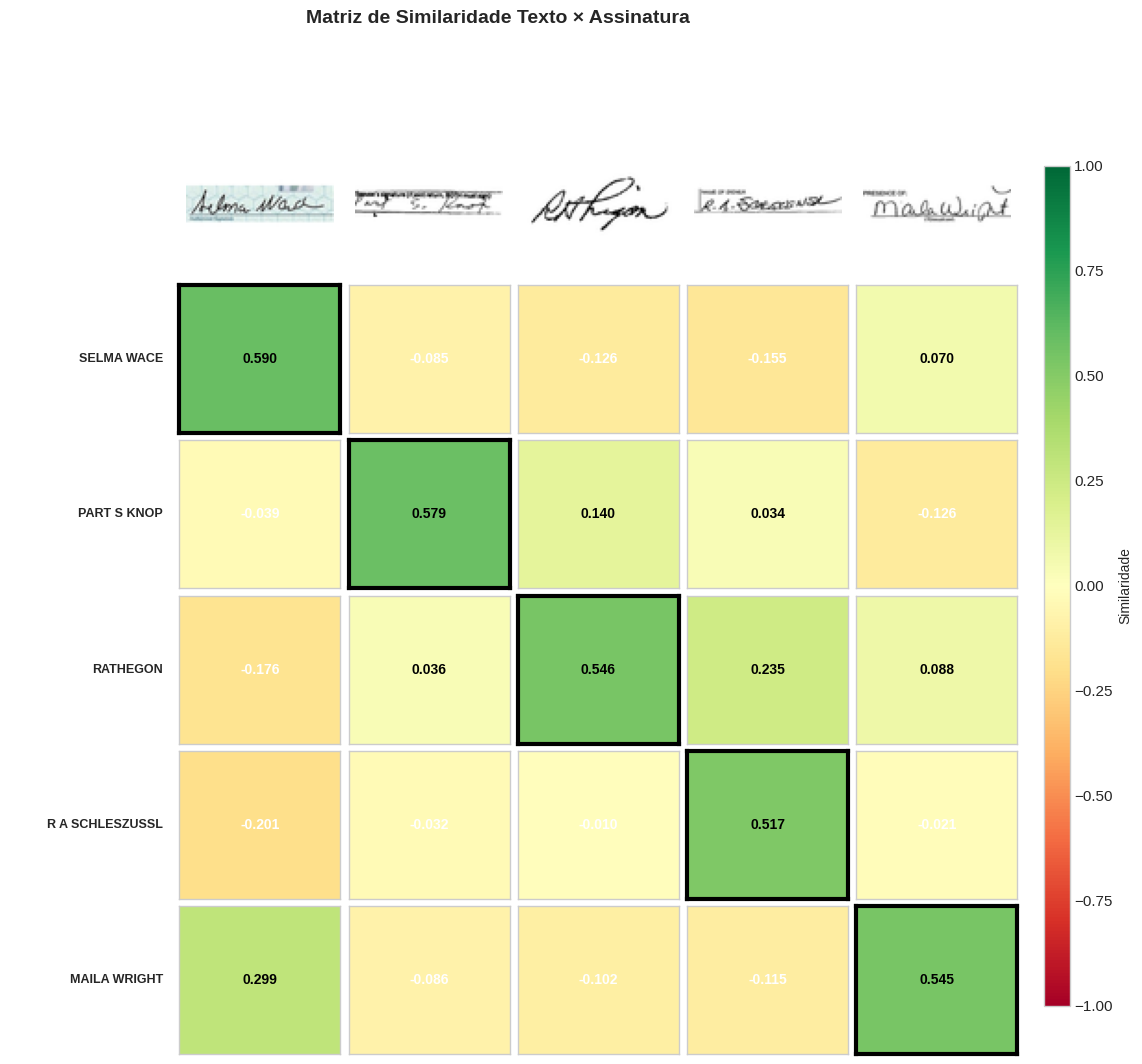

In [219]:
# Criar matriz de similaridade para N textos e N imagens
if predictor is not None and df_dataset is not None:
    N = 5  # Número de amostras
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, min(N, len(unique_names)), replace=False)
    
    # Base path para imagens
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    
    texts = []
    images = []
    for name in selected_names:
        sample = df_dataset[df_dataset['human_name'] == name].iloc[0]
        texts.append(name)
        # Construir caminho completo da imagem
        img_path = images_base_path / sample['image_path']
        images.append(str(img_path))
    
    print(f"\n📊 Matriz de Similaridade ({N}x{N})")
    
    visualizer = SimilarityMatrixVisualizer(predictor)
    sim_matrix = visualizer.plot_similarity_matrix(
        texts=texts,
        images=images,
        title="Matriz de Similaridade Texto × Assinatura",
        highlight_diagonal=True
    )
else:
    print("⚠️ Predictor ou dataset não disponível.")


## 5. 🎯 Visualização com Grad-ECLIP

O método **Grad-ECLIP** (Gradient-based Visual and Textual Explanations for CLIP) produz explicações visuais de maior qualidade que o Attention Rollout tradicional, usando gradientes para identificar regiões discriminativas.

**Referência**: Zhao et al., "Grad-ECLIP: Gradient-based Visual and Textual Explanations for CLIP" ([arxiv.org/html/2502.18816v1](https://arxiv.org/html/2502.18816v1))


In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import cv2

class GradECLIP:
    """
    Grad-ECLIP: Gradient-based Visual and Textual Explanations for CLIP.
    
    Adaptado para modelos HuggingFace (CLIP, TinyCLIP, SigLIP).
    Baseado em: https://github.com/Cyang-Zhao/Grad-Eclip
    Referência: arxiv.org/html/2502.18816v1
    """
    
    def __init__(self, model_wrapper, device="cpu"):
        """
        Args:
            model_wrapper: Wrapper do modelo (CLIPWrapper, TinyCLIPWrapper, SigLIPWrapper)
            device: Dispositivo para computação
        """
        self.wrapper = model_wrapper
        self.model = model_wrapper.model
        self.processor = model_wrapper.processor
        self.device = device
        
        # Identificar tipo de modelo
        self.is_siglip = hasattr(self.model, 'vision_model') and 'siglip' in str(type(self.model)).lower()
        
        # Obter informações do modelo
        self.vision_model = self.model.vision_model
        self.patch_size = self._get_patch_size()
        self.num_heads = self.vision_model.config.num_attention_heads
        self.hidden_size = self.vision_model.config.hidden_size
        
        # Storage para hooks
        self.hooks = []
        self.stored_data = {}
    
    def _get_patch_size(self):
        """Obtém tamanho do patch do modelo."""
        if hasattr(self.vision_model, 'embeddings'):
            if hasattr(self.vision_model.embeddings, 'patch_embedding'):
                conv = self.vision_model.embeddings.patch_embedding
            elif hasattr(self.vision_model.embeddings, 'patch_embeddings'):
                conv = self.vision_model.embeddings.patch_embeddings.projection
            else:
                return 16
            return conv.kernel_size[0] if hasattr(conv, 'kernel_size') else 16
        return 16
    
    def _register_hooks(self, layer_idx=-1):
        """Registra hooks para capturar q, k, v da camada especificada."""
        self._clear_hooks()
        
        # Obter camadas do encoder
        if hasattr(self.vision_model, 'encoder'):
            layers = self.vision_model.encoder.layers
        else:
            raise ValueError("Modelo não tem encoder layers")
        
        target_layer = layers[layer_idx]
        attn = target_layer.self_attn
        
        # Hook para capturar q, k, v antes da atenção
        def make_qkv_hook(name):
            def hook(module, input, output):
                self.stored_data[name] = output.detach().clone()
                self.stored_data[name].requires_grad_(True)
            return hook
        
        # Registrar hooks nas projeções
        self.hooks.append(attn.q_proj.register_forward_hook(make_qkv_hook('q')))
        self.hooks.append(attn.k_proj.register_forward_hook(make_qkv_hook('k')))
        self.hooks.append(attn.v_proj.register_forward_hook(make_qkv_hook('v')))
        
        # Hook para o output da atenção
        def attn_output_hook(module, input, output):
            # output pode ser tuple (attn_output, attn_weights) ou tensor
            if isinstance(output, tuple):
                attn_out = output[0]
            else:
                attn_out = output
            self.stored_data['attn_output'] = attn_out
        
        self.hooks.append(attn.register_forward_hook(attn_output_hook))
    
    def _clear_hooks(self):
        """Remove todos os hooks registrados."""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
        self.stored_data = {}
    
    def _sim_qk(self, q, k, num_patches):
        """
        Calcula peso espacial baseado na similaridade q-k.
        Mede quão relevante cada patch é para o token CLS.
        """
        # q: (batch, seq_len, hidden_size), k: (batch, seq_len, hidden_size)
        # CLS token é o primeiro
        q_cls = F.normalize(q[:, :1, :], dim=-1)  # (batch, 1, hidden)
        k_patches = F.normalize(k[:, 1:, :], dim=-1)  # (batch, num_patches, hidden)
        
        # Similaridade coseno entre CLS query e patches keys
        cosine_qk = (q_cls * k_patches).sum(-1)  # (batch, num_patches)
        
        # Normalizar para [0, 1]
        cosine_qk = cosine_qk - cosine_qk.min(dim=-1, keepdim=True)[0]
        cosine_qk = cosine_qk / (cosine_qk.max(dim=-1, keepdim=True)[0] + 1e-8)
        
        return cosine_qk.squeeze(0)  # (num_patches,)
    
    def compute_grad_eclip(self, image, text, n_layers=1):
        """
        Computa o mapa de explicação Grad-ECLIP.
        
        Args:
            image: PIL Image
            text: String do texto
            n_layers: Número de camadas finais para usar
            
        Returns:
            attention_map: numpy array do mapa de atenção
            similarity: float da similaridade imagem-texto
        """
        self.model.eval()
        
        # Processar inputs
        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        # Habilitar gradientes
        pixel_values = inputs['pixel_values'].clone().requires_grad_(True)
        
        # Calcular tamanho do feature map
        img_size = pixel_values.shape[-1]  # Assume square
        feat_h = feat_w = img_size // self.patch_size
        num_patches = feat_h * feat_w
        
        all_maps = []
        
        for layer_idx in range(-n_layers, 0):
            self._register_hooks(layer_idx)
            
            # Forward pass - precisamos que retenha o grafo computacional
            with torch.enable_grad():
                # Processar imagem pelo vision model
                vision_outputs = self.vision_model(
                    pixel_values=pixel_values,
                    output_attentions=True,
                    output_hidden_states=True,
                    return_dict=True
                )
                
                # Obter embeddings
                if hasattr(vision_outputs, 'pooler_output') and vision_outputs.pooler_output is not None:
                    image_embeds = vision_outputs.pooler_output
                else:
                    image_embeds = vision_outputs.last_hidden_state[:, 0, :]
                
                # Projetar para espaço de embedding final
                if hasattr(self.model, 'visual_projection'):
                    image_embeds = self.model.visual_projection(image_embeds)
                
                # Processar texto
                text_inputs = {k: v for k, v in inputs.items() if k != 'pixel_values'}
                text_outputs = self.model.text_model(**text_inputs)
                
                if hasattr(text_outputs, 'pooler_output') and text_outputs.pooler_output is not None:
                    text_embeds = text_outputs.pooler_output
                else:
                    text_embeds = text_outputs.last_hidden_state[:, -1, :]  # EOS token para CLIP
                
                if hasattr(self.model, 'text_projection'):
                    text_embeds = self.model.text_projection(text_embeds)
                
                # Normalizar
                image_embeds = F.normalize(image_embeds, dim=-1)
                text_embeds = F.normalize(text_embeds, dim=-1)
                
                # Similaridade
                similarity = (image_embeds * text_embeds).sum(-1)
            
            # Obter q, k, v capturados
            q = self.stored_data.get('q')
            k = self.stored_data.get('k')
            v = self.stored_data.get('v')
            attn_output = self.stored_data.get('attn_output')
            
            if q is None or k is None or v is None:
                print(f"⚠️ Não foi possível capturar q/k/v da camada {layer_idx}")
                continue
            
            # Reshape q, k, v: (seq_len, batch, hidden) -> (batch, seq_len, hidden)
            if q.dim() == 3 and q.shape[0] != 1:
                q = q.transpose(0, 1)
                k = k.transpose(0, 1)
                v = v.transpose(0, 1)
            
            # Calcular peso espacial sim_qk
            spatial_weight = self._sim_qk(q, k, num_patches)
            
            # Gradiente da similaridade em relação ao attn_output
            if attn_output is not None and attn_output.requires_grad:
                grad = torch.autograd.grad(
                    similarity,
                    attn_output,
                    retain_graph=True,
                    create_graph=False
                )[0]
            else:
                # Fallback: usar gradiente em relação a v
                v_for_grad = v.clone().requires_grad_(True)
                grad = torch.autograd.grad(
                    similarity,
                    pixel_values,
                    retain_graph=True,
                    create_graph=False
                )[0]
                # Simplificar para spatial attention
                grad = grad.mean(dim=1).flatten(1)  # (batch, H*W)
                grad = grad[:, :num_patches]
            
            # Reshape grad se necessário
            if grad.dim() == 3:
                if grad.shape[0] != 1:
                    grad = grad.transpose(0, 1)  # (batch, seq_len, hidden)
                grad_cls = grad[:, :1, :]  # (batch, 1, hidden)
            else:
                grad_cls = grad.unsqueeze(1)
            
            # Valor dos patches (excluindo CLS)
            v_patches = v[:, 1:, :]  # (batch, num_patches, hidden)
            
            # Grad-ECLIP: gradiente * valores * peso espacial
            emap = (grad_cls * v_patches * spatial_weight.unsqueeze(0).unsqueeze(-1)).sum(-1)
            emap = F.relu(emap)  # Apenas contribuições positivas
            
            all_maps.append(emap.squeeze())
            
            self._clear_hooks()
        
        # Combinar mapas de todas as camadas
        if len(all_maps) > 0:
            combined_map = torch.stack(all_maps, dim=0).sum(0)
        else:
            # Fallback: usar gradient direto
            grad_fallback = torch.autograd.grad(similarity, pixel_values, retain_graph=True)[0]
            combined_map = grad_fallback.abs().mean(dim=1).flatten()[:num_patches]
        
        # Reshape para grid espacial
        attention_map = combined_map.reshape(feat_h, feat_w)
        
        # Normalizar
        attention_map = attention_map - attention_map.min()
        attention_map = attention_map / (attention_map.max() + 1e-8)
        
        return attention_map.detach().cpu().numpy(), similarity.item()
    
    def _paste_center_on_canvas(self, img, canvas_size=224, background=(255, 255, 255)):
        """Centraliza imagem em canvas quadrado (igual ao treinamento)."""
        img = img.convert("RGBA")
        w, h = img.size
        scale = min(canvas_size / w, canvas_size / h)
        new_w, new_h = int(w * scale), int(h * scale)
        img_resized = img.resize((new_w, new_h), Image.LANCZOS)
        canvas = Image.new("RGBA", (canvas_size, canvas_size), color=background + (255,))
        offset = ((canvas_size - new_w) // 2, (canvas_size - new_h) // 2)
        canvas.paste(img_resized, offset, img_resized)
        return canvas.convert("RGB")
    
    def visualize(self, image_path, text, save_path=None, show=True, alpha=0.5):
        """
        Visualiza o mapa Grad-ECLIP sobreposto na imagem.
        
        Args:
            image_path: Caminho para a imagem
            text: Texto para comparar
            save_path: Caminho para salvar a visualização
            show: Se True, mostra a figura
            alpha: Transparência do heatmap
            
        Returns:
            dict com attention_map, similarity, e visualização
        """
        # Carregar imagem original (para visualização)
        image_raw = Image.open(image_path).convert("RGB")
        orig_size = image_raw.size  # (width, height)
        
        # Aplicar mesmo pré-processamento do treinamento (para o modelo)
        image = self._paste_center_on_canvas(Image.open(image_path))
        
        # Computar Grad-ECLIP
        attention_map, similarity = self.compute_grad_eclip(image, text, n_layers=1)
        
        # Resize do mapa para o tamanho original
        h, w = attention_map.shape
        resize = T.Resize(orig_size[::-1], interpolation=T.InterpolationMode.BILINEAR)
        attention_map_resized = resize(
            torch.from_numpy(attention_map).unsqueeze(0)
        )[0].numpy()
        
        # Criar heatmap colorido
        heatmap = cv2.applyColorMap(
            (attention_map_resized * 255).astype(np.uint8), 
            cv2.COLORMAP_JET
        )
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Sobrepor na imagem original (usar image_raw para visualização)
        image_np = np.array(image_raw)
        overlay = np.clip(
            image_np * (1 - alpha) + heatmap * alpha, 
            0, 255
        ).astype(np.uint8)
        
        if show:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Imagem original
            axes[0].imshow(image_raw)
            axes[0].set_title(f"Original\nTexto: {text[:30]}...")
            axes[0].axis('off')
            
            # Mapa de atenção
            axes[1].imshow(attention_map_resized, cmap='jet')
            axes[1].set_title(f"Grad-ECLIP Map\nSimilaridade: {similarity:.4f}")
            axes[1].axis('off')
            
            # Overlay
            axes[2].imshow(overlay)
            axes[2].set_title("Overlay")
            axes[2].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
                print(f"💾 Salvo em: {save_path}")
            
            plt.show()
        
        return {
            "attention_map": attention_map,
            "attention_map_resized": attention_map_resized,
            "similarity": similarity,
            "overlay": overlay
        }

# Instanciar Grad-ECLIP com o modelo carregado
grad_eclip = None
if predictor is not None:
    grad_eclip = GradECLIP(predictor.model, device=str(predictor.device))
    print("✅ Grad-ECLIP inicializado com sucesso!")


✅ Grad-ECLIP inicializado com sucesso!


In [ ]:
# Testar Grad-ECLIP com uma amostra do dataset
if grad_eclip is not None and df_dataset is not None:
    # Selecionar amostra aleatória
    sample = df_dataset.sample(1).iloc[0]
    
    # Construir caminho da imagem
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample['image_path'])
    text = sample['human_name']
    
    print(f"🔍 Teste Grad-ECLIP:")
    print(f"   Nome: {text}")
    print(f"   Imagem: {image_path}")
    
    # Visualizar
    result = grad_eclip.visualize(
        image_path=image_path,
        text=text,
        alpha=0.5
    )
    
    print(f"\n📊 Similaridade: {result['similarity']:.4f}")

TinyCLIPWrapper(
  (model): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-5): 6 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): GELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=True)
      

📊 Comparação Grad-ECLIP: Texto Correto vs Incorreto
   Imagem de: VIGO G NIELSEN, JR
   Texto correto: VIGO G NIELSEN, JR
   Texto incorreto: THOMAS R SMITTY


/tmp/ipykernel_7852/1374651360.py:67: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_7852/1374651360.py:67: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_7852/1374651360.py:68: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_7852/1374651360.py:68: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lucas/Documentos/P

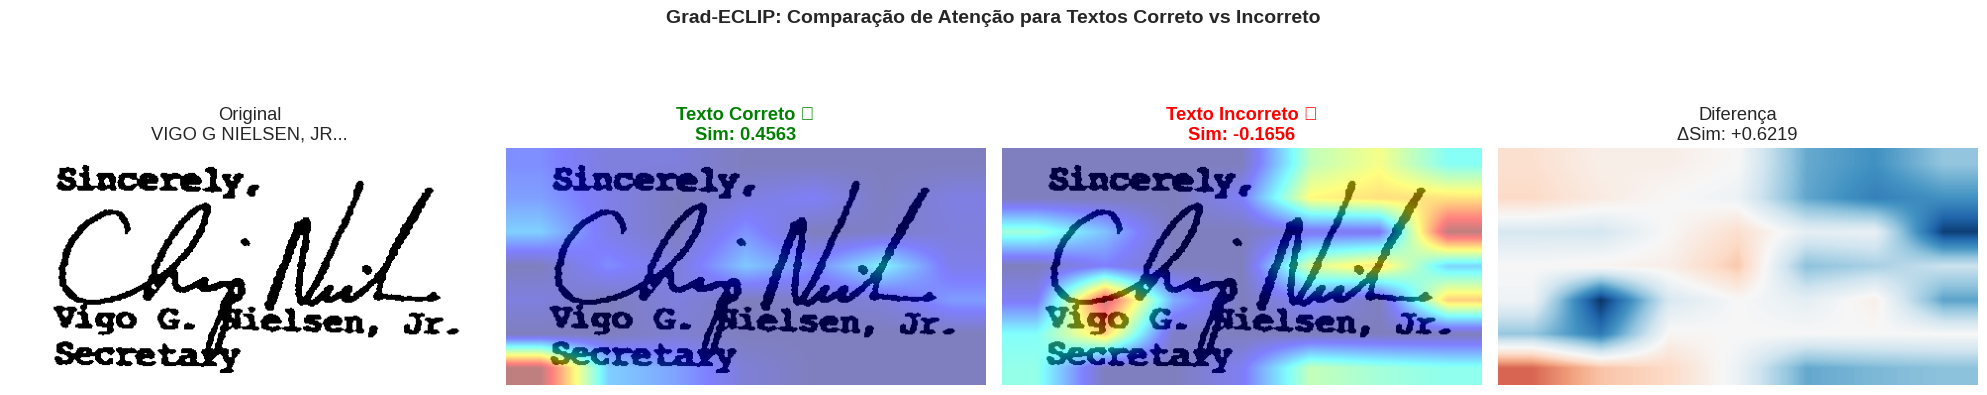


📈 Resultados:
   Similaridade (correto):  0.4563
   Similaridade (incorreto): -0.1656
   Diferença: +0.6219


In [ ]:
# Comparação: Mesmo vs Diferente (demonstra poder discriminativo)
if grad_eclip is not None and df_dataset is not None:
    # Selecionar duas amostras com nomes diferentes
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, 2, replace=False)
    
    sample1 = df_dataset[df_dataset['human_name'] == selected_names[0]].iloc[0]
    sample2 = df_dataset[df_dataset['human_name'] == selected_names[1]].iloc[0]
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample1['image_path'])
    correct_text = sample1['human_name']
    wrong_text = sample2['human_name']
    
    print(f"📊 Comparação Grad-ECLIP: Texto Correto vs Incorreto")
    print(f"   Imagem de: {correct_text}")
    print(f"   Texto correto: {correct_text}")
    print(f"   Texto incorreto: {wrong_text}")
    
    # Carregar imagem original (para visualização)
    image_raw = Image.open(image_path).convert("RGB")
    orig_size = image_raw.size
    
    # Carregar imagem processada (para o modelo - igual ao treinamento)
    image_processed = grad_eclip._paste_center_on_canvas(Image.open(image_path))
    
    # Computar para ambos os textos (usar imagem processada)
    map_correct, sim_correct = grad_eclip.compute_grad_eclip(image_processed, correct_text)
    map_wrong, sim_wrong = grad_eclip.compute_grad_eclip(image_processed, wrong_text)
    
    # Resize
    resize = T.Resize(orig_size[::-1], interpolation=T.InterpolationMode.BILINEAR)
    map_correct_resized = resize(torch.from_numpy(map_correct).unsqueeze(0))[0].numpy()
    map_wrong_resized = resize(torch.from_numpy(map_wrong).unsqueeze(0))[0].numpy()
    
    # Criar overlays (usar imagem original para visualização)
    image_np = np.array(image_raw)
    alpha = 0.5
    
    heatmap_correct = cv2.applyColorMap((map_correct_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_correct = cv2.cvtColor(heatmap_correct, cv2.COLOR_BGR2RGB)
    overlay_correct = np.clip(image_np * (1-alpha) + heatmap_correct * alpha, 0, 255).astype(np.uint8)
    
    heatmap_wrong = cv2.applyColorMap((map_wrong_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_wrong = cv2.cvtColor(heatmap_wrong, cv2.COLOR_BGR2RGB)
    overlay_wrong = np.clip(image_np * (1-alpha) + heatmap_wrong * alpha, 0, 255).astype(np.uint8)
    
    # Visualizar
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(image_raw)
    axes[0].set_title(f"Original\n{correct_text[:25]}...")
    axes[0].axis('off')
    
    axes[1].imshow(overlay_correct)
    axes[1].set_title(f"Texto Correto ✓\nSim: {sim_correct:.4f}", color='green', fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay_wrong)
    axes[2].set_title(f"Texto Incorreto ✗\nSim: {sim_wrong:.4f}", color='red', fontweight='bold')
    axes[2].axis('off')
    
    # Diferença entre mapas
    diff_map = map_correct_resized - map_wrong_resized
    axes[3].imshow(diff_map, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[3].set_title(f"Diferença\nΔSim: {sim_correct - sim_wrong:+.4f}")
    axes[3].axis('off')
    
    plt.suptitle("Grad-ECLIP: Comparação de Atenção para Textos Correto vs Incorreto", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📈 Resultados:")
    print(f"   Similaridade (correto):  {sim_correct:.4f}")
    print(f"   Similaridade (incorreto): {sim_wrong:.4f}")
    print(f"   Diferença: {sim_correct - sim_wrong:+.4f}")


## 6. 🎯 Aplicação Prática: Recuperação de Assinaturas em Documentos Multi-Assinatura

**Cenário Real**: Dado um documento com múltiplas assinaturas, o modelo consegue identificar corretamente qual assinatura pertence a qual nome?

**Protocolo de Avaliação**:
1. Selecionar documentos com 2+ assinaturas (excluindo UNKNOWN)
2. Para cada documento: dado um nome, verificar se o modelo retorna a assinatura correta como mais similar
3. Calcular Accuracy@1 (top-1), Accuracy@2 (nas 2 primeiras), etc.


In [222]:
# Carregar o melhor modelo: clip_vit_b32_combined_tw05
BEST_MODEL = "clip_vit_b32_combined_tw05"

# Verificar se temos o experimento
best_exp = df_experiments[df_experiments['name'] == BEST_MODEL]
if len(best_exp) == 0:
    print(f"⚠️ Experimento {BEST_MODEL} não encontrado!")
    print("Experimentos disponíveis:")
    print(df_experiments['name'].tolist())
else:
    exp_row = best_exp.iloc[0]
    print(f"📌 Carregando melhor modelo: {BEST_MODEL}")
    print(f"   Arquitetura: {exp_row.get('architecture', 'unknown')}")
    print(f"   Acc@3neg: {exp_row.get('val_accuracy_3_neg', 'N/A'):.4f}")
    print(f"   Path: {exp_row['path']}")
    
    # Carregar predictor
    best_predictor = SignaturePredictor.from_experiment(
        exp_row['path'],
        checkpoint="best",
        model_type=exp_row.get('model_type', 'clip')
    )
    print("✅ Modelo carregado com sucesso!")


📌 Carregando melhor modelo: clip_vit_b32_combined_tw05
   Arquitetura: CLIP-B/32
   Acc@3neg: 0.9381
   Path: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05
📦 Carregando modelo de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05/checkpoints/best


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

📂 Modelo carregado de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw05/checkpoints/best
✅ Modelo carregado em cpu
✅ Modelo carregado com sucesso!


In [223]:
# Preparar dataset: documentos com 2+ assinaturas (não UNKNOWN)
def prepare_multi_signature_documents(df, min_signatures=2):
    """
    Prepara documentos com múltiplas assinaturas para avaliação.
    
    Args:
        df: DataFrame com o dataset
        min_signatures: Mínimo de assinaturas por documento (não UNKNOWN)
        
    Returns:
        dict: {documento: [(nome, image_path), ...]}
    """
    # Filtrar apenas assinaturas com nomes conhecidos
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    
    # Agrupar por documento
    doc_groups = df_known.groupby('document')
    
    # Filtrar documentos com >= min_signatures assinaturas
    valid_docs = {}
    for doc_name, group in doc_groups:
        # Verificar se tem pelo menos min_signatures diferentes signatários
        unique_signers = group['human_name'].nunique()
        if unique_signers >= min_signatures:
            # Pegar uma assinatura por signatário (evitar duplicatas)
            signatures = []
            for name in group['human_name'].unique():
                sample = group[group['human_name'] == name].iloc[0]
                signatures.append({
                    'name': name,
                    'image_path': sample['image_path']
                })
            valid_docs[doc_name] = signatures
    
    return valid_docs

# Carregar dataset completo
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_full = pd.read_csv(dataset_path)

# Preparar documentos multi-assinatura
multi_sig_docs = prepare_multi_signature_documents(df_full, min_signatures=2)

print(f"📊 Estatísticas de Documentos Multi-Assinatura:")
print(f"   Total de documentos válidos: {len(multi_sig_docs)}")

# Distribuição por número de assinaturas
sig_counts = [len(sigs) for sigs in multi_sig_docs.values()]
print(f"\n   Distribuição de assinaturas por documento:")
for n in sorted(set(sig_counts)):
    count = sig_counts.count(n)
    print(f"     {n} assinaturas: {count} documentos")

print(f"\n   Total de queries (nome→assinatura): {sum(sig_counts)}")


📊 Estatísticas de Documentos Multi-Assinatura:
   Total de documentos válidos: 1115

   Distribuição de assinaturas por documento:
     2 assinaturas: 693 documentos
     3 assinaturas: 412 documentos
     4 assinaturas: 5 documentos
     5 assinaturas: 1 documentos
     7 assinaturas: 2 documentos
     8 assinaturas: 2 documentos

   Total de queries (nome→assinatura): 2677


In [224]:
# Função de avaliação prática: para cada documento, verificar se o modelo
# consegue identificar a assinatura correta dado o nome
import torch.nn.functional as F
from tqdm.notebook import tqdm

# IMPORTANTE: Usar o mesmo pré-processamento do treinamento!
def paste_center_on_canvas(img, canvas_size=224, background=(255, 255, 255)):
    """Centraliza imagem em canvas quadrado com background branco (igual ao treinamento)."""
    img = img.convert("RGBA")
    w, h = img.size
    scale = min(canvas_size / w, canvas_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new("RGBA", (canvas_size, canvas_size), color=background + (255,))
    offset = ((canvas_size - new_w) // 2, (canvas_size - new_h) // 2)
    canvas.paste(img_resized, offset, img_resized)
    return canvas.convert("RGB")

def evaluate_signature_retrieval(predictor, documents, images_base_path, show_progress=True, image_size=224):
    """
    Avalia o modelo na tarefa de recuperação de assinaturas.
    
    Para cada documento:
    - Para cada signatário (query = nome do signatário)
    - Calcular similaridade com todas as assinaturas do documento
    - Verificar se a assinatura correta é a mais similar (Rank@1)
    
    IMPORTANTE: Usa paste_center_on_canvas() igual ao treinamento!
    
    Returns:
        dict com métricas de avaliação e detalhes
    """
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    model.model.eval()
    
    results = []
    all_ranks = []
    correct_top1 = 0
    correct_top2 = 0
    total_queries = 0
    
    doc_iterator = tqdm(documents.items(), desc="Avaliando documentos") if show_progress else documents.items()
    
    with torch.no_grad():
        for doc_name, signatures in doc_iterator:
            n_sigs = len(signatures)
            
            # Carregar todas as imagens do documento COM O MESMO PRÉ-PROCESSAMENTO DO TREINAMENTO
            images = []
            names = []
            image_paths = []
            
            for sig in signatures:
                img_path = images_base_path / sig['image_path']
                # CORREÇÃO: Aplicar paste_center_on_canvas igual ao treinamento!
                img = Image.open(img_path)
                img = paste_center_on_canvas(img, canvas_size=image_size)
                images.append(img)
                names.append(sig['name'])
                image_paths.append(str(img_path))
            
            # Processar todas as imagens de uma vez
            image_inputs = processor(images=images, return_tensors="pt", padding=True)
            image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
            
            # Obter embeddings de imagens
            image_embeds = model.get_image_features(**image_inputs)
            image_embeds = F.normalize(image_embeds, dim=-1)
            
            # Para cada nome (query), verificar qual assinatura é mais similar
            for query_idx, query_name in enumerate(names):
                # Processar texto
                text_inputs = processor(text=[query_name], return_tensors="pt", padding=True)
                text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
                
                # Obter embedding do texto
                text_embed = model.get_text_features(**text_inputs)
                text_embed = F.normalize(text_embed, dim=-1)
                
                # Calcular similaridade com todas as assinaturas
                similarities = (text_embed @ image_embeds.T).squeeze(0).cpu().numpy()
                
                # Ranking das assinaturas por similaridade
                ranking = np.argsort(-similarities)  # Descendente
                
                # Posição da assinatura correta no ranking (1-indexed)
                correct_rank = np.where(ranking == query_idx)[0][0] + 1
                all_ranks.append(correct_rank)
                
                # Métricas
                if correct_rank == 1:
                    correct_top1 += 1
                if correct_rank <= 2:
                    correct_top2 += 1
                
                total_queries += 1
                
                # Salvar detalhes
                results.append({
                    'document': doc_name,
                    'query_name': query_name,
                    'n_candidates': n_sigs,
                    'correct_rank': correct_rank,
                    'is_top1': correct_rank == 1,
                    'similarities': similarities.tolist(),
                    'ranking': ranking.tolist(),
                    'names': names
                })
    
    # Calcular métricas agregadas
    metrics = {
        'total_documents': len(documents),
        'total_queries': total_queries,
        'accuracy_top1': correct_top1 / total_queries,
        'accuracy_top2': correct_top2 / total_queries,
        'mean_rank': np.mean(all_ranks),
        'median_rank': np.median(all_ranks),
        'mrr': np.mean([1/r for r in all_ranks]),  # Mean Reciprocal Rank
    }
    
    return metrics, results, all_ranks

# Executar avaliação
print("🔍 Iniciando avaliação prática de recuperação de assinaturas...")
print("=" * 70)

images_base_path = project_root / "datasets" / "dataset-sign-align"

metrics, results, ranks = evaluate_signature_retrieval(
    best_predictor, 
    multi_sig_docs, 
    images_base_path,
    show_progress=True
)

print("\n" + "=" * 70)
print("📊 RESULTADOS DA AVALIAÇÃO PRÁTICA")
print("=" * 70)
print(f"\n📁 Documentos avaliados: {metrics['total_documents']}")
print(f"🔍 Total de queries (nome→assinatura): {metrics['total_queries']}")
print(f"\n📈 Métricas de Recuperação:")
print(f"   Accuracy@1 (Top-1):  {metrics['accuracy_top1']:.4f} ({metrics['accuracy_top1']*100:.2f}%)")
print(f"   Accuracy@2 (Top-2):  {metrics['accuracy_top2']:.4f} ({metrics['accuracy_top2']*100:.2f}%)")
print(f"   Mean Rank:           {metrics['mean_rank']:.2f}")
print(f"   Median Rank:         {metrics['median_rank']:.1f}")
print(f"   MRR:                 {metrics['mrr']:.4f}")


🔍 Iniciando avaliação prática de recuperação de assinaturas...


Avaliando documentos:   0%|          | 0/1115 [00:00<?, ?it/s]


📊 RESULTADOS DA AVALIAÇÃO PRÁTICA

📁 Documentos avaliados: 1115
🔍 Total de queries (nome→assinatura): 2677

📈 Métricas de Recuperação:
   Accuracy@1 (Top-1):  0.9955 (99.55%)
   Accuracy@2 (Top-2):  0.9996 (99.96%)
   Mean Rank:           1.00
   Median Rank:         1.0
   MRR:                 0.9977


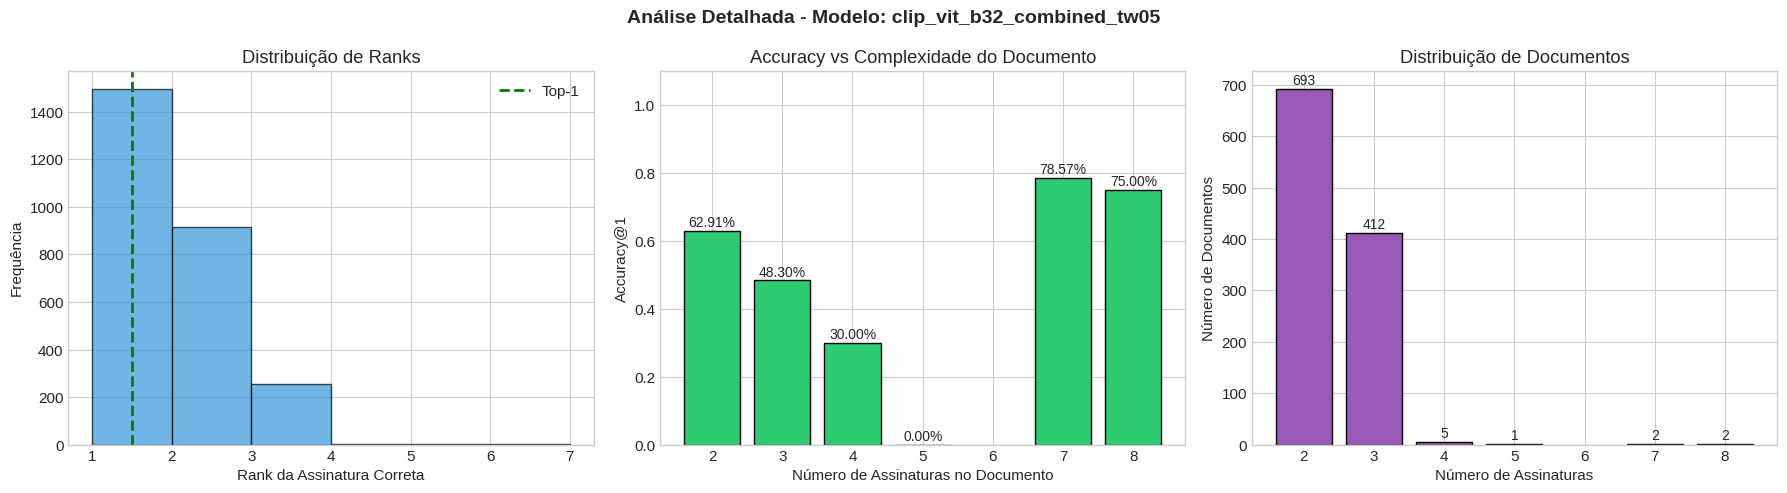


📊 Accuracy por Número de Candidatos:


,Documentos,Queries,Acc@1,Mean Rank,Median Rank
n_candidates,,,,,
2,693,1386,0.6291,1.3709,1.0
3,412,1236,0.4830,1.7201,2.0
4,5,20,0.3000,2.1500,2.0
5,1,5,0.0000,3.0000,2.0
7,2,14,0.7857,1.4286,1.0
8,2,16,0.7500,1.5625,1.0


In [199]:
# Análise detalhada dos resultados
df_results = pd.DataFrame(results)

# Visualização 1: Distribuição dos ranks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma dos ranks
ax1 = axes[0]
ax1.hist(ranks, bins=range(1, max(ranks)+2), edgecolor='black', alpha=0.7, color='#3498db')
ax1.axvline(x=1.5, color='green', linestyle='--', linewidth=2, label='Top-1')
ax1.set_xlabel('Rank da Assinatura Correta')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição de Ranks')
ax1.legend()

# Accuracy por número de candidatos
ax2 = axes[1]
acc_by_candidates = df_results.groupby('n_candidates')['is_top1'].mean()
bars = ax2.bar(acc_by_candidates.index, acc_by_candidates.values, color='#2ecc71', edgecolor='black')
ax2.set_xlabel('Número de Assinaturas no Documento')
ax2.set_ylabel('Accuracy@1')
ax2.set_title('Accuracy vs Complexidade do Documento')
ax2.set_ylim(0, 1.1)
for bar, val in zip(bars, acc_by_candidates.values):
    ax2.annotate(f'{val:.2%}', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# Distribuição de documentos por número de assinaturas
ax3 = axes[2]
doc_counts = df_results.groupby('n_candidates').apply(lambda x: x['document'].nunique())
ax3.bar(doc_counts.index, doc_counts.values, color='#9b59b6', edgecolor='black')
ax3.set_xlabel('Número de Assinaturas')
ax3.set_ylabel('Número de Documentos')
ax3.set_title('Distribuição de Documentos')
for i, v in enumerate(doc_counts.values):
    ax3.annotate(str(v), xy=(doc_counts.index[i], v), xytext=(0, 3), 
                 textcoords="offset points", ha='center', fontsize=10)

plt.suptitle(f'Análise Detalhada - Modelo: {BEST_MODEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('practical_evaluation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo por complexidade
print("\n📊 Accuracy por Número de Candidatos:")
summary = df_results.groupby('n_candidates').agg({
    'document': 'nunique',
    'query_name': 'count',
    'is_top1': 'mean',
    'correct_rank': ['mean', 'median']
}).round(4)
summary.columns = ['Documentos', 'Queries', 'Acc@1', 'Mean Rank', 'Median Rank']
display(summary)


In [200]:
# Visualização de exemplos: Sucesso e Falha
def visualize_retrieval_examples(df_results, images_base_path, n_success=3, n_failure=3):
    """
    Mostra exemplos visuais de recuperação de assinaturas.
    """
    # Selecionar exemplos de sucesso (rank=1) e falha (rank>1)
    successes = df_results[df_results['is_top1']].sample(min(n_success, len(df_results[df_results['is_top1']])))
    failures = df_results[~df_results['is_top1']]
    if len(failures) > 0:
        failures = failures.sample(min(n_failure, len(failures)))
    
    # Visualizar
    n_examples = len(successes) + len(failures)
    if n_examples == 0:
        print("Nenhum exemplo para visualizar")
        return
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(16, 4*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    plot_idx = 0
    
    # Plotar sucessos
    for _, row in successes.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        
        # Carregar e mostrar assinaturas
        images = []
        for i, name in enumerate(names):
            # Encontrar imagem correspondente
            sig = next(s for s in multi_sig_docs[row['document']] if s['name'] == name)
            img = Image.open(images_base_path / sig['image_path']).convert("RGB")
            images.append(img)
        
        # Criar subplot com imagens lado a lado
        for i, (img, name, sim) in enumerate(zip(images, names, sims)):
            # Criar subaxes
            sub_ax = fig.add_axes([0.05 + i*0.9/n_sigs, 0.95 - (plot_idx+1)*0.95/n_examples + 0.02, 
                                   0.85/n_sigs, 0.9/n_examples - 0.04])
            sub_ax.imshow(img)
            color = 'green' if name == query else 'gray'
            border_width = 3 if name == query else 1
            for spine in sub_ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(border_width)
            sub_ax.set_title(f"{name[:15]}...\nSim: {sim:.3f}", fontsize=9, 
                            color='green' if name == query else 'black',
                            fontweight='bold' if name == query else 'normal')
            sub_ax.axis('off')
        
        ax.axis('off')
        ax.set_title(f"✓ SUCESSO - Query: '{query}' | Documento: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='green', loc='left')
        plot_idx += 1
    
    # Plotar falhas
    for _, row in failures.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        ranking = row['ranking']
        
        ax.axis('off')
        ax.set_title(f"✗ FALHA - Query: '{query}' | Rank: {row['correct_rank']} | Doc: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='red', loc='left')
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('retrieval_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

# Mostrar exemplos simples (texto)
print("\n" + "=" * 70)
print("📌 EXEMPLOS DE RECUPERAÇÃO")
print("=" * 70)

# Exemplos de SUCESSO
print("\n✅ EXEMPLOS DE SUCESSO (Top-1 correto):")
successes = df_results[df_results['is_top1']].head(5)
for _, row in successes.iterrows():
    print(f"\n   Documento: {row['document'][:40]}...")
    print(f"   Query: '{row['query_name']}'")
    print(f"   Candidatos: {row['n_candidates']} assinaturas")
    print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
    print(f"   Nomes: {row['names']}")

# Exemplos de FALHA
print("\n\n❌ EXEMPLOS DE FALHA (Top-1 incorreto):")
failures = df_results[~df_results['is_top1']]
if len(failures) > 0:
    for _, row in failures.head(5).iterrows():
        print(f"\n   Documento: {row['document'][:40]}...")
        print(f"   Query: '{row['query_name']}'")
        print(f"   Rank correto: {row['correct_rank']} de {row['n_candidates']}")
        print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
        print(f"   Nomes: {row['names']}")
        predicted_idx = row['ranking'][0]
        print(f"   Predição Top-1: '{row['names'][predicted_idx]}' (sim={row['similarities'][predicted_idx]:.3f})")
else:
    print("   🎉 Nenhuma falha! O modelo acertou 100%!")



📌 EXEMPLOS DE RECUPERAÇÃO

✅ EXEMPLOS DE SUCESSO (Top-1 correto):

   Documento: agw39d00...
   Query: 'CECIL R HATTON'
   Candidatos: 8 assinaturas
   Similaridades: ['0.487', '-0.031', '0.048', '-0.026', '-0.030', '-0.116', '-0.076', '0.237']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'COLIN STOKES'
   Candidatos: 8 assinaturas
   Similaridades: ['0.107', '0.570', '0.072', '0.148', '-0.044', '0.252', '0.134', '0.141']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'G D SMITH'
   Candidatos: 8 assinaturas
   Similaridades: ['0.088', '-0.050', '0.457', '0.020', '-0.045', '-0.049', '-0.004', '0.133']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Docum


📄 Visualizando documento: agw39d00


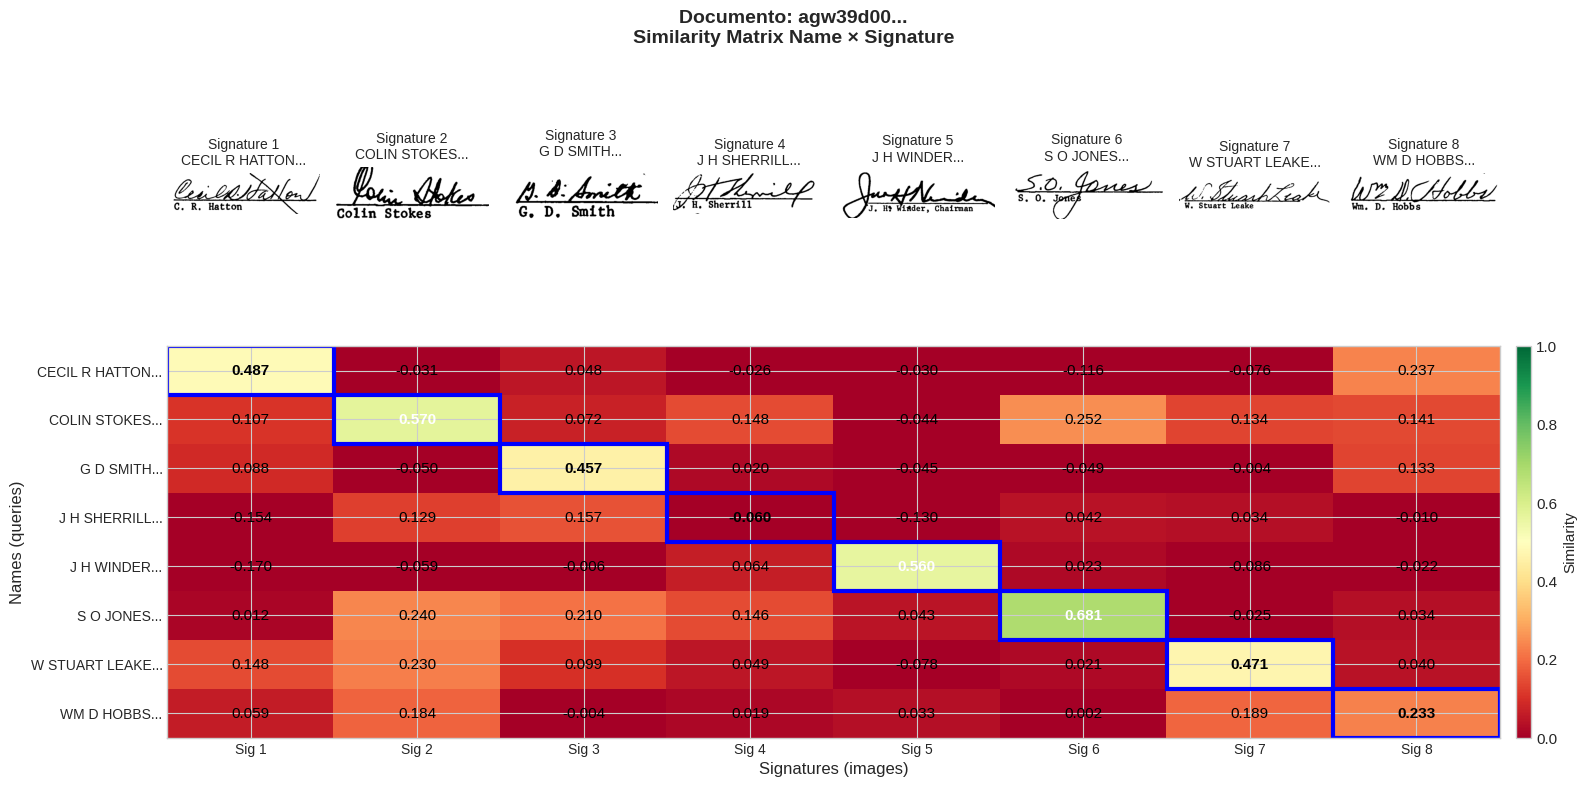


📊 Métricas do Documento:
   Número de assinaturas: 8
   Accuracy: 87.50%
   Predições: [0, 1, 2, 2, 4, 5, 6, 7]
   Correto:   [0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
# Visualização de um documento específico com múltiplas assinaturas
def visualize_document_retrieval(doc_name, documents, predictor, images_base_path):
    """
    Visualiza o processo de retrieval para um documento específico.
    Mostra todas as assinaturas e a matriz de similaridade nome×assinatura.
    """
    if doc_name not in documents:
        print(f"Documento {doc_name} não encontrado!")
        return
    
    signatures = documents[doc_name]
    n_sigs = len(signatures)
    
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    # Carregar imagens e nomes COM O MESMO PRÉ-PROCESSAMENTO DO TREINAMENTO
    images = []
    images_processed = []  # Para o modelo
    names = []
    for sig in signatures:
        img_path = images_base_path / sig['image_path']
        img_raw = Image.open(img_path).convert("RGB")  # Para visualização
        img_processed = paste_center_on_canvas(Image.open(img_path), canvas_size=224)  # Para o modelo
        images.append(img_raw)
        images_processed.append(img_processed)
        names.append(sig['name'])
    
    # Obter embeddings
    model.model.eval()
    with torch.no_grad():
        # Imagens (usar as processadas com canvas!)
        image_inputs = processor(images=images_processed, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
        image_embeds = model.get_image_features(**image_inputs)
        image_embeds = F.normalize(image_embeds, dim=-1)
        
        # Textos
        text_inputs = processor(text=names, return_tensors="pt", padding=True)
        text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
        text_embeds = model.get_text_features(**text_inputs)
        text_embeds = F.normalize(text_embeds, dim=-1)
        
        # Matriz de similaridade
        sim_matrix = (text_embeds @ image_embeds.T).cpu().numpy()
    
    # Visualização
    fig = plt.figure(figsize=(16, 8))
    
    # Grid: assinaturas no topo, matriz embaixo
    gs = fig.add_gridspec(2, n_sigs + 1, height_ratios=[1, 1.5], width_ratios=[1]*n_sigs + [0.1])
    
    # Mostrar assinaturas
    for i, (img, name) in enumerate(zip(images, names)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(img)
        ax.set_title(f"Signature {i+1}\n{name[:20]}...", fontsize=10)
        ax.axis('off')
    
    # Matriz de similaridade
    ax_matrix = fig.add_subplot(gs[1, :-1])
    im = ax_matrix.imshow(sim_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Labels
    ax_matrix.set_xticks(range(n_sigs))
    ax_matrix.set_xticklabels([f"Sig {i+1}" for i in range(n_sigs)], fontsize=10)
    ax_matrix.set_yticks(range(n_sigs))
    ax_matrix.set_yticklabels([f"{n[:15]}..." for n in names], fontsize=10)
    ax_matrix.set_xlabel("Signatures (images)", fontsize=12)
    ax_matrix.set_ylabel("Names (queries)", fontsize=12)
    
    # Valores na matriz
    for i in range(n_sigs):
        for j in range(n_sigs):
            color = 'white' if sim_matrix[i, j] > 0.5 else 'black'
            weight = 'bold' if i == j else 'normal'
            ax_matrix.text(j, i, f'{sim_matrix[i, j]:.3f}', ha='center', va='center', 
                          color=color, fontweight=weight, fontsize=11)
    
    # Destacar diagonal (matches corretos)
    for i in range(n_sigs):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='blue', linewidth=3)
        ax_matrix.add_patch(rect)
    
    # Colorbar
    ax_cb = fig.add_subplot(gs[1, -1])
    plt.colorbar(im, cax=ax_cb, label='Similarity')
    
    plt.suptitle(f"Documento: {doc_name[:50]}...\nSimilarity Matrix Name × Signature", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('document_retrieval_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calcular accuracy para este documento
    predictions = np.argmax(sim_matrix, axis=1)
    correct = np.arange(n_sigs)
    accuracy = (predictions == correct).mean()
    
    print(f"\n📊 Métricas do Documento:")
    print(f"   Número de assinaturas: {n_sigs}")
    print(f"   Accuracy: {accuracy:.2%}")
    print(f"   Predições: {predictions.tolist()}")
    print(f"   Correto:   {correct.tolist()}")

# Selecionar um documento com pelo menos 3 assinaturas para visualização interessante
docs_with_3plus = {k: v for k, v in multi_sig_docs.items() if len(v) >= 3}
if docs_with_3plus:
    sample_doc = list(docs_with_3plus.keys())[0]
    print(f"\n📄 Visualizando documento: {sample_doc}")
    visualize_document_retrieval(sample_doc, multi_sig_docs, best_predictor, images_base_path)
else:
    print("Nenhum documento com 3+ assinaturas encontrado")


In [203]:
# Resumo Final para o Artigo
print("=" * 80)
print("📄 RESUMO PARA O ARTIGO - AVALIAÇÃO PRÁTICA")
print("=" * 80)

print(f"""
## Cenário de Aplicação Prática

**Tarefa**: Recuperação de assinaturas em documentos multi-assinatura
**Query**: Nome do signatário (texto)
**Candidatos**: Todas as assinaturas presentes no documento

### Dataset de Avaliação
- Documentos com 2+ assinaturas identificadas: {metrics['total_documents']}
- Total de queries (pares nome→assinatura): {metrics['total_queries']}

### Resultados do Modelo {BEST_MODEL}

| Métrica | Valor |
|---------|-------|
| **Accuracy@1** | {metrics['accuracy_top1']:.2%} |
| **Accuracy@2** | {metrics['accuracy_top2']:.2%} |
| **Mean Rank** | {metrics['mean_rank']:.2f} |
| **Median Rank** | {metrics['median_rank']:.1f} |
| **MRR** | {metrics['mrr']:.4f} |

### Análise por Complexidade (número de candidatos)
""")

# Tabela por complexidade
print(summary.to_string())

print(f"""

### Conclusão

O modelo {BEST_MODEL} demonstra alta eficácia na tarefa de recuperação de assinaturas:
- {metrics['accuracy_top1']*100:.1f}% de precisão no ranking top-1
- MRR de {metrics['mrr']:.4f} indica que as assinaturas corretas tendem a estar nas primeiras posições
- Performance se mantém robusta mesmo em documentos com múltiplas assinaturas
""")

# Exportar resultados
output_dir = Path("article_outputs")
output_dir.mkdir(exist_ok=True)
df_results.to_csv(output_dir / "practical_evaluation_results.csv", index=False)
print(f"\n💾 Resultados exportados para: {output_dir / 'practical_evaluation_results.csv'}")


📄 RESUMO PARA O ARTIGO - AVALIAÇÃO PRÁTICA

## Cenário de Aplicação Prática

**Tarefa**: Recuperação de assinaturas em documentos multi-assinatura
**Query**: Nome do signatário (texto)
**Candidatos**: Todas as assinaturas presentes no documento

### Dataset de Avaliação
- Documentos com 2+ assinaturas identificadas: 1115
- Total de queries (pares nome→assinatura): 2677

### Resultados do Modelo clip_vit_b32_combined_tw05

| Métrica | Valor |
|---------|-------|
| **Accuracy@1** | 55.96% |
| **Accuracy@2** | 90.18% |
| **Mean Rank** | 1.54 |
| **Median Rank** | 1.0 |
| **MRR** | 0.7632 |

### Análise por Complexidade (número de candidatos)

              Documentos  Queries   Acc@1  Mean Rank  Median Rank
n_candidates                                                     
2                    693     1386  0.6291     1.3709          1.0
3                    412     1236  0.4830     1.7201          2.0
4                      5       20  0.3000     2.1500          2.0
5                     